# Figure 5 — PI+VC Individual Differences by Cognitive Cluster

Reconstructs Figure 5 of the 2S2C manuscript from the rebuilt parquet
pipeline. Unlike Figs 2–4, this figure analyzes a **single group**: the
**PI+VC (fixed 2nd cue) rats, n = 17**. The rebuild reproduces the published
result exactly.

**The analysis.** A k-means cluster analysis (k = 3) partitions the 17 rats
on three probe scores, with a fourth (Reversal) **held out** as an
independent external-validation measure:

| variable | session phase | scoring | denom |
|---|---|---|---|
| **Novel Route** (clustering) | `Novel Route` | novel-route trials (post-trial-16, `correct_route` = the session's novel sequence) with `errors == 0` | /16 |
| **No Cue** (clustering) | `No Cue` | all trials `errors == 0` | /32 |
| **Rotation** (clustering) | `Rotation` | all trials `errors == 0` | /16 |
| **Reversal** (held out) | `Reversal` | `(64 − trials_to_criterion) / 56`, trials to criterion = 8 × the first Phase-2 block with 8/8 correct (`REV_SCORE = '8of8_block'`, the Fig 4 criterion, adopted 2026-09-24; never reached = 64). Rats whose session ended before such a block (CM006, CM007) are unscorable and are excluded from every Reversal-dependent panel and statistic (n = 15) | 0–1 |

Clustering pipeline (exact port of the legacy `pivc_f2_clustering_3var_k3.py`
→ `figure_5.py`): z-score the three variables → PCA → because the first two
PCs explain > 80 % of variance (66.4 % + 23.8 % = 90.2 %), cluster in **2-D
PC space** → k-means (k = 3, `n_init = 50`, `random_state = 42`) → relabel
clusters by ascending Novel-Route mean → name by profile.

**Three subtypes** (manuscript means in parentheses; Reversal = the 8/8 block score over the scored rats, 4 / 6 / 5):

| cluster | n | Novel Route | No Cue | Rotation | Reversal |
|---|---|---|---|---|---|
| **VC-Dominant** | 4 | 3.25 (3.25) | 20.0 (20.0) | 13.0 (13.0) | 0.29 (0.29) |
| **Flexible-Strategists** | 6 | 11.7 (11.7) | 26.0 (26.0) | 12.8 (12.8) | 0.67 (0.67) |
| **PI-Dominant** | 7 (5 with Reversal) | 12.1 (12.1) | 26.1 (26.1) | 8.7 (8.7) | 0.71 (0.71) |

**Panels** (two rows — A B C / D E — 180 mm full page width, the Wiley canvas; 2.0-in row cells). The clustering validation that
was Supplementary Figure 3 is folded in here as Panel A (right), B, C and
E (left).
- **A** — 3-D scatter of the three probe scores (proportions), colored by
  cluster (carries the stacked cluster legend), alongside the z-scored
  behavioral profile of each cluster (mean ± SEM across rats) on the three
  clustering variables **and** the held-out Reversal score.
- **B** — Cluster-number selection: the Gap statistic (500 reference
  datasets) and the Calinski-Harabasz index both independently select k = 3.
- **C** — PCA of the three clustering variables (PC1 × PC2) with 95 %
  confidence ellipses; the three clusters separate cleanly.
- **D** — Acquisition learning curves aligned to the criterion session
  (session 0), median % correct per cluster + individual rat points.
- **E** — External validation on the held-out Reversal score (n = 15, see the
  scoring table). Left: per-rat Reversal score by cluster (mean ± SEM). The
  classical one-way ANOVA (F(2, 12) = 6.64, p = .012) rests on grossly unequal
  variances (two VC-Dominant rats at the floor; Levene p = .005), so the strip is
  annotated with the log-rank p (.028) on trials to criterion with the two
  never-reversed rats right-censored at 64 (the censoring-aware test the
  manuscript leans on, as in Fig 4C); Welch (p = .16) and Kruskal–Wallis
  (p = .071) are printed in the stats cell. Right: each probe score (raw correct trials)
  vs Reversal, with stacked top marginals and a shared right marginal. Dashed
  lines = the one-sided binomial p < .01 above-chance thresholds (Novel Route
  9/16 at chance .25, No Cue 24/32 and Rotation 14/16 at chance .5).


## Preamble — imports, paths, style


In [1]:
from pathlib import Path
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator
from matplotlib.patches import Ellipse, Patch
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers 3d projection)
from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import calinski_harabasz_score

PROJECT_ROOT = Path.cwd().parents[1]   # figures/notebooks/ -> repo root
DATA = PROJECT_ROOT / 'data' / 'processed'
CONFIG = PROJECT_ROOT / 'config'
FIG_OUT = PROJECT_ROOT / 'figures' / 'images'
FIG_OUT.mkdir(exist_ok=True)

RNG_SEED = 42  # fixes k-means / gap-statistic refs / jitter — reproduces the published partition

pd.set_option('display.max_columns', None, 'display.width', 200)


In [2]:
# Cluster order is fixed by ascending Novel-Route mean (assigned below):
#   0 = VC-Dominant, 1 = Flexible-Strategists, 2 = PI-Dominant.
CLUSTER_ORDER = ['VC-Dominant', 'Flexible-Strategists', 'PI-Dominant']

# Display order for legends, the profile bars (Panel A, right) and the Reversal
# strip (Panel E, left). Independent of CLUSTER_ORDER (= cluster index 0/1/2,
# fixed by the relabel step) — reorder freely. Short labels = strip x ticks.
DISPLAY_ORDER = ['VC-Dominant', 'PI-Dominant', 'Flexible-Strategists']
CLUSTER_SHORT = {'VC-Dominant': 'VC', 'PI-Dominant': 'PI', 'Flexible-Strategists': 'Flex'}

# Cluster colors matched to the training-group palette used in Figs 2-4
# (Wong/Nature, from docs/journal_figure_specs.md): each cluster takes the
# hue of its namesake group. 'dark' = base hue, 'light' = fill tint. Tunable.
#   'dark' = base hue, 'light' = fill tint, 'edge' = dark shade (marker edge /
#   error bars), 'hatch' = mid-tone hatch color — all from the Figs 2-4 palette.
CLUSTER_COLORS = {
    'VC-Dominant':      {'dark': '#E69F00', 'light': '#F4CF80', 'edge': '#8A5F00', 'hatch': '#EDB740'},  # = VC     (orange)
    'Flexible-Strategists': {'dark': '#009E73', 'light': '#8FD4BE', 'edge': '#00624A', 'hatch': '#47B998'},  # = PI+VC  (green)
    'PI-Dominant':      {'dark': '#56B4E9', 'light': '#AADCF4', 'edge': '#2B6F94', 'hatch': '#80C8EE'},  # = PI     (sky blue)
}

# Line style also matched to the group palette (redundant encoding, Figs 2-4):
#   PI+VC solid '-', PI dashed '--', VC dash-dot '-.'.
CLUSTER_LINE = {
    'VC-Dominant':      '-.',   # = VC
    'Flexible-Strategists': '-',    # = PI+VC
    'PI-Dominant':      '--',   # = PI
}

# Marker (node) shape also matched to the group palette (Figs 2-4):
#   PI+VC circle 'o', PI square 's', VC triangle '^'.
CLUSTER_MARKER = {
    'VC-Dominant':      '^',    # = VC
    'Flexible-Strategists': 'o',    # = PI+VC
    'PI-Dominant':      's',    # = PI
}

# Hatch pattern for bar/histogram fills, matched to the group palette
# (Figs 2-3 redundant encoding): PI+VC none, PI diagonal '///', VC dots '...'.
CLUSTER_HATCH = {
    'VC-Dominant':      '...',  # = VC
    'Flexible-Strategists': '',     # = PI+VC (no hatch)
    'PI-Dominant':      '///',  # = PI
}

# Metric colors for Panel B (the two k-selection curves — not cluster colors).
# Wong blue + vermillion: the two unclaimed members of the manuscript's Wong
# palette. CVD-validated 2026-08-31 (OKLab dE, Machado sims): within-pair 21.9
# worst; >= 9.5 vs every group color. The old seaborn pair failed (red vs
# Flexible-Strategists green dE 5.1 under deuteranopia).
COLOR_GAP = '#0072B2'   # Wong blue
COLOR_CH  = '#D55E00'   # Wong vermillion

# Panel B marker faces: a light TINT of each curve's colour, so the points read as
# light nodes rather than solid blobs. Same idea as the cluster palette's 'light'
# entries (base blended toward white). The lines, marker edges, error bars and the
# axis titles all stay at full strength, so the colour coding is unchanged.
MARKER_TINT = 0.50        # 0 = the base colour, 1 = white
def _tint(hex_color, f=None):
    '''Blend a hex colour f of the way toward white.'''
    f = MARKER_TINT if f is None else f
    r, g, b = (int(hex_color[i:i + 2], 16) for i in (1, 3, 5))
    return '#%02X%02X%02X' % tuple(round(c + (255 - c) * f) for c in (r, g, b))
COLOR_GAP_FILL = _tint(COLOR_GAP)
COLOR_CH_FILL  = _tint(COLOR_CH)

STYLE_CFG = {
    'scatter_s':        18,     # panel E dot size (scatters + Reversal strip)
    'scatter_alpha':    0.7,
    'scatter3d_s':      26,     # panel A / C dot size
    'marker_edge_lw':   0.6,    # panel D node edge (dark shade) — matches Fig 4
    'marker_size':      3.2,    # panel D node diameter (pt)     — matches Fig 4
    'err_lw':           0.9,    # panel D IQR bar + cap thickness
    'cap_size':         2,      # panel D error-bar cap size
    'line_lw':          1.2,    # panel D median line
    'ind_scatter_s':    12,     # panel D individual points (per-group shape)
    'ind_scatter_alpha': 0.25,  # base-hue group color, faint (50% lighter)
    'threshold_lw':     0.8,
    'threshold_color':  '#AAAAAA',
    'baseline_color':   '0.65',  # panel E marginal-histogram baselines (light)
    'baseline_lw':      0.75,
    'legend_frame_lw':  0.5,
    'legend_content_color': '0.3',
    'bar_edge_lw':      0.5,    # panel A profile bars (outline + hatch strokes)
    'bar_err_lw':       0.8,    # panel A profile SEM bars
    'divider_color':    '0.85', # panel A profile between-variable dividers
    'ellipse_alpha':    0.25,   # panel C 95% confidence ellipses
    'strip_mean_lw':    1.0,    # panel E strip mean tick
    'strip_err_lw':     0.9,    # panel E strip SEM bars
}

plt.rcParams.update({
    'font.family': 'Helvetica',
    'font.size': 8,
    'mathtext.default': 'regular',
    'axes.labelsize': 7,
    'axes.titlesize': 7,
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'legend.fontsize': 6,
    'axes.linewidth': 0.75,
    'xtick.major.width': 0.75,
    'ytick.major.width': 0.75,
    'lines.linewidth': 0.75,
    'patch.linewidth': 0.75,
    'hatch.linewidth': 0.75,  # panel A bars / panel E marginal-histogram hatch strokes
                              # (= Figs 2-4; at 0.5 the VC dots rendered as thin
                              #  rings instead of the solid dots of the group bars)
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'figure.dpi': 200,
    'savefig.dpi': 300,
})

# --- Helvetica bold / oblique faces ------------------------------------------
# macOS ships Helvetica as a .ttc collection and matplotlib's font manager indexes
# only its first face (Regular, weight 400), so fontweight='bold' silently fell back
# to regular (the PDF embedded no Helvetica-Bold). Split the collection into
# standalone .ttf faces once (user-local, outside the repo) and register them so
# 'bold' resolves to Helvetica-Bold.ttf. Same block as figure2/figure3.
from matplotlib import font_manager as _fm
_HELV_TTC = Path('/System/Library/Fonts/Helvetica.ttc')
_HELV_DIR = Path.home() / '.matplotlib' / 'helvetica_faces'
if _HELV_TTC.exists():
    if not any(_HELV_DIR.glob('*.ttf')):
        from fontTools.ttLib import TTCollection
        _HELV_DIR.mkdir(parents=True, exist_ok=True)
        for _face in TTCollection(str(_HELV_TTC)).fonts:
            _face.save(str(_HELV_DIR / f"{_face['name'].getDebugName(6)}.ttf"))
    for _p in _HELV_DIR.glob('*.ttf'):
        _fm.fontManager.addfont(str(_p))
_bold_face = Path(_fm.findfont(_fm.FontProperties(family='Helvetica', weight='bold'))).name
if 'Bold' not in _bold_face:
    print(f'WARNING: Helvetica bold resolved to {_bold_face}; panel letters will render regular')
else:
    print(f'Helvetica bold face: {_bold_face}')

def _clean_spine(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


Helvetica bold face: Helvetica-Bold.ttf


## Load cohort and parquets


In [3]:
cohort = yaml.safe_load((CONFIG / 'subjects.yaml').read_text())['figure5']
cohort_ids = [sid for ids in cohort.values() for sid in ids]

subjects = pd.read_parquet(DATA / 'subjects.parquet')
sessions = pd.read_parquet(DATA / 'sessions.parquet')
trials   = pd.read_parquet(DATA / 'trials.parquet')

subjects = subjects[subjects['subject_id'].isin(cohort_ids)].copy()
assert len(subjects) == 17, f'expected 17 PI+VC rats, got {len(subjects)}'
assert (subjects['training_group'] == 'PI+VC').all(), 'non-PI+VC rat in cohort'

# Attach subject_id + phase to trials, restricted to the cohort.
sp = sessions[sessions['subject_id'].isin(cohort_ids)][
    ['session_id', 'subject_id', 'session_experiment_phase']]
ptrials = (trials.merge(sp, on='session_id', how='inner')
                 .sort_values(['session_id', 'trial_number']))

print(f'Cohort: PI+VC n={len(subjects)}')
print('Probe sessions per rat (each rat should have exactly 1 of each):')
print(ptrials[ptrials['session_experiment_phase']
              .isin(['Novel Route', 'No Cue', 'Rotation', 'Reversal'])]
      .drop_duplicates('session_id')
      .groupby('session_experiment_phase', observed=True)['subject_id']
      .nunique().to_string())


Cohort: PI+VC n=17
Probe sessions per rat (each rat should have exactly 1 of each):
session_experiment_phase
Novel Route    17
Reversal       17
Rotation       17
No Cue         17


## Probe scores

Exact port of the legacy `build_pandas_table.py` scoring. A trial is
"correct" iff `errors == 0` (no wrong-well visits, per
`project_errors_definition`).


In [4]:
# --- Reversal (held out) --------------------------------------------------------
# REV_SCORE selects the trials-to-criterion rule behind the held-out Reversal score:
#   '8of8_block'   : first Phase-2 block of 8 with REV_CRIT_CORRECT_OF_8 correct;
#                    trials to criterion = 8 x block. This is figure4's
#                    criterion (adopted 2026-09-24) so Figs 4 and 5 agree. Rats whose
#                    session ended (< REV_MAX_TRIALS reversal trials) before such a
#                    block cannot be scored: with REV_EXCLUDE_UNMET they are dropped
#                    from every Reversal-dependent statistic and panel (CM006, CM007);
#                    rats that ran all 64 trials without one are censored at 64.
#   'legacy_window': the original build_pandas_table.py rule - sliding 8-trial window
#                    from trial 17, first window with 7 of 8 correct (or 7 consecutive),
#                    trials to criterion = index of the window's last trial (min 7).
# The score rescales trials to criterion to 0-1: 1 = criterion at the earliest possible
# point (block 1 = 8 trials; legacy 7), 0 = never within REV_MAX_TRIALS.
REV_SCORE = '8of8_block'
REV_CRIT_CORRECT_OF_8 = 8
REV_EXCLUDE_UNMET = True
REV_MAX_TRIALS = 64
REV_MIN_TTC = {'8of8_block': 8, 'legacy_window': 7}[REV_SCORE]

def reversal_trials_crit_legacy(trial_scores):
    '''Trials-to-criterion in the reversal phase (exact legacy port).

    Slides an 8-trial window from trial index 16 (= first reversal trial).
    Criterion = 8/8, or 7/8 where the 8th window trial is the error. Counter
    starts at 7 and increments per step; returns 64 if never met.
    '''
    s = list(trial_scores)
    k = 7
    for i in range(16, 81):
        window = s[i:i + 8]
        perfect = window.count(0)
        eighth_err = (i + 7) < len(s) and s[i + 7] > 0
        if (perfect == 7 and eighth_err) or perfect == 8:
            return k
        elif perfect == 7:
            return k + 1
        k += 1
    return 64

def reversal_trials_crit_block(rev_trials):
    '''Trials to criterion under the block rule (REV_SCORE = '8of8_block').

    Phase-2 trials (trial_number > 16) are grouped into blocks of 8; the first
    block with >= REV_CRIT_CORRECT_OF_8 correct (errors == 0) trials gives
    8 x block. Returns REV_MAX_TRIALS (censored) when the rat ran the full 64
    trials without one, and NaN when the session ended earlier without one.
    '''
    p2 = rev_trials[rev_trials['trial_number'] > 16]
    blk = (p2['trial_number'] - 17) // 8 + 1
    correct = (p2['errors'] == 0).groupby(blk).sum()
    hit = correct[correct >= REV_CRIT_CORRECT_OF_8]
    if len(hit):
        return 8.0 * int(hit.index[0])
    return float(REV_MAX_TRIALS) if len(p2) >= REV_MAX_TRIALS else np.nan

rows = []
for sid, name in subjects[['subject_id', 'name']].itertuples(index=False):
    t = ptrials[ptrials['subject_id'] == sid]
    r = {'subject_id': sid, 'name': name}

    # Novel Route — post-16 novel-route trials, errors==0, /16.
    # Novel route = most-frequent Phase-2 correct_route (frame-invariant;
    # matches figure3). PI+VC is a fixed frame so this = the novel start arm.
    nr = t[(t['session_experiment_phase'] == 'Novel Route') &
           (t['trial_number'] > 16)]
    novel_seq = nr['correct_route'].value_counts().idxmax()
    novel = nr[nr['correct_route'] == novel_seq]
    r['nr_rscr'] = int((novel['errors'] == 0).sum())
    r['nr_scr'] = r['nr_rscr'] / 16

    # No Cue — all trials errors==0, /32.
    nc = t[t['session_experiment_phase'] == 'No Cue']
    r['nc_rscr'] = int((nc['errors'] == 0).sum())
    r['nc_scr'] = r['nc_rscr'] / 32

    # Rotation — all trials errors==0, /16.
    ro = t[t['session_experiment_phase'] == 'Rotation']
    r['rot_rscr'] = int((ro['errors'] == 0).sum())
    r['rot_scr'] = r['rot_rscr'] / 16

    # Reversal (held out) — trials to criterion per REV_SCORE, rescaled to 0-1.
    rv = t[t['session_experiment_phase'] == 'Reversal']
    r['rev_n_trials'] = int((rv['trial_number'] > 16).sum())
    if REV_SCORE == '8of8_block':
        ttc = reversal_trials_crit_block(rv)
    else:
        ttc = float(reversal_trials_crit_legacy(rv['errors'].tolist()))
    if np.isnan(ttc) and not REV_EXCLUDE_UNMET:
        ttc = float(REV_MAX_TRIALS)          # scored as never reached (not criterion-based)
    r['rev_rscr'] = ttc
    r['rev_scr'] = (REV_MAX_TRIALS - ttc) / (REV_MAX_TRIALS - REV_MIN_TTC)
    rows.append(r)

scores = pd.DataFrame(rows)
rev_unscored = scores.loc[scores['rev_scr'].isna(), 'name'].tolist()
N_REV = int(scores['rev_scr'].notna().sum())
print(f'Reversal score rule: {REV_SCORE}; {N_REV} of {len(scores)} rats scored; '
      f'unscorable (session ended before a {REV_CRIT_CORRECT_OF_8}/8 block, excluded from the '
      f'Reversal-dependent panels and statistics): {", ".join(rev_unscored) or "none"}')
# Sanity: trial counts per probe (NR novel=16, NoCue=32, Rot=16)
print('Score ranges (raw correct trials; rev_rscr = trials to criterion):')
print(scores[['nr_rscr', 'nc_rscr', 'rot_rscr', 'rev_n_trials', 'rev_rscr', 'rev_scr']]
      .describe().round(2).to_string())
scores.head(20)


Reversal score rule: 8of8_block; 15 of 17 rats scored; unscorable (session ended before a 8/8 block, excluded from the Reversal-dependent panels and statistics): CM006, CM007
Score ranges (raw correct trials; rev_rscr = trials to criterion):
       nr_rscr  nc_rscr  rot_rscr  rev_n_trials  rev_rscr  rev_scr
count    17.00    17.00     17.00         17.00     15.00    15.00
mean      9.88    24.65     11.18         36.47     31.47     0.58
std       4.37     3.30      2.32         14.15     14.33     0.26
min       0.00    18.00      8.00         24.00     16.00     0.00
25%       9.00    23.00      9.00         25.00     24.00     0.57
50%      12.00    25.00     12.00         32.00     24.00     0.71
75%      13.00    26.00     13.00         40.00     32.00     0.71
max      15.00    29.00     14.00         64.00     64.00     0.86


,subject_id,name,nr_rscr,nr_scr,nc_rscr,nc_scr,rot_rscr,rot_scr,rev_n_trials,rev_rscr,rev_scr
0,47,CM000,7,0.4375,18,0.56250,13,0.8125,32,24.0,0.714286
1,48,CM001,0,0.0000,18,0.56250,14,0.8750,64,64.0,0.000000
2,49,CM002,9,0.5625,26,0.81250,11,0.6875,32,32.0,0.571429
3,50,CM003,14,0.8750,26,0.81250,8,0.5000,24,24.0,0.714286
4,51,CM004,1,0.0625,23,0.71875,13,0.8125,64,64.0,0.000000
5,52,CM005,13,0.8125,26,0.81250,13,0.8125,32,32.0,0.571429
6,53,CM006,12,0.7500,23,0.71875,8,0.5000,32,NaN,NaN
7,54,CM007,12,0.7500,25,0.78125,10,0.6250,32,NaN,NaN
8,55,CM008,9,0.5625,25,0.78125,8,0.5000,32,32.0,0.571429
9,56,CM009,5,0.3125,21,0.65625,12,0.7500,40,40.0,0.428571


## Clustering (k = 3)

z-score the three clustering variables → PCA → cluster in 2-D PC space
(2 PCs > 80 % variance) → k-means (k = 3) → relabel by ascending Novel-Route
mean → name by profile.


In [5]:
CLUSTER_VARS = ['nr_scr', 'nc_scr', 'rot_scr']   # proportions
VALIDATION_VAR = 'rev_scr'                       # held out of the clustering
ALL_VARS = CLUSTER_VARS + [VALIDATION_VAR]
NICE = {'nr_scr': 'Novel Route', 'nc_scr': 'No Cue',
        'rot_scr': 'Rotation', 'rev_scr': 'Reversal'}

X_raw = scores[CLUSTER_VARS].to_numpy(float)
X_z = StandardScaler().fit_transform(X_raw)

pca = PCA().fit(X_z)
PC = pca.transform(X_z)
var = pca.explained_variance_ratio_
cum2 = var[:2].sum()
print(f'PCA variance explained: PC1={var[0]:.3f}, PC2={var[1]:.3f}, '
      f'PC3={var[2]:.3f}  (cum2={cum2:.3f})')

X_cluster = PC[:, :2] if cum2 > 0.80 else X_z
print(f'Clustering space: {"2-D PC" if cum2 > 0.80 else "3-D z-scored"}')

km = KMeans(n_clusters=3, n_init=50, random_state=RNG_SEED).fit(X_cluster)
raw_labels = km.labels_

# Relabel clusters by ascending Novel-Route mean (0 = lowest NR).
order = sorted(range(3), key=lambda c: X_raw[raw_labels == c, 0].mean())
remap = {old: new for new, old in enumerate(order)}
scores['cluster'] = [remap[l] for l in raw_labels]

# Name each cluster by its profile (thresholds from legacy figure_5.py).
name_by_idx = {}
for c in range(3):
    m = scores['cluster'] == c
    nr_m, rot_m = scores.loc[m, 'nr_scr'].mean(), scores.loc[m, 'rot_scr'].mean()
    name_by_idx[c] = ('VC-Dominant' if nr_m < 0.5
                      else 'Flexible-Strategists' if rot_m > 0.7 else 'PI-Dominant')
scores['cluster_name'] = scores['cluster'].map(name_by_idx)
assert [name_by_idx[c] for c in range(3)] == CLUSTER_ORDER, \
    f'cluster naming/order mismatch: {name_by_idx}'

# PC / raw arrays keyed to scores row order (used by the panels).
scores['PC1'], scores['PC2'] = PC[:, 0], PC[:, 1]


PCA variance explained: PC1=0.664, PC2=0.238, PC3=0.098  (cum2=0.902)
Clustering space: 2-D PC


In [6]:
# Reproduce the manuscript's per-cluster table (raw counts + normalized Reversal).
# Reversal (REV_SCORE) is averaged over the scored rats only (n_rev).
prof = (scores.groupby('cluster_name', observed=True)
        .agg(n=('subject_id', 'size'), n_rev=('rev_scr', 'count'),
             NovelRoute=('nr_rscr', 'mean'), NoCue=('nc_rscr', 'mean'),
             Rotation=('rot_rscr', 'mean'), Reversal=('rev_scr', 'mean'))
        .reindex(CLUSTER_ORDER).round(2))
print('Reconstructed cluster profiles:')
print(prof.to_string())
print()
print('Manuscript targets (2026-09-24; Reversal = 8/8 block score over n_rev = 4 / 6 / 5):')
print('  VC-Dominant           4   3.25  20.00  13.00  0.29')
print('  Flexible-Strategists  6  11.70  26.00  12.80  0.67')
print('  PI-Dominant           7  12.10  26.10   8.70  0.71')

expected_n = {'VC-Dominant': 4, 'Flexible-Strategists': 6, 'PI-Dominant': 7}
for nm, n in expected_n.items():
    got = int(prof.loc[nm, 'n'])
    assert got == n, f'{nm}: n={got}, expected {n}'
print('\nOK: cluster sizes match the manuscript (4 / 6 / 7 = 17).')


Reconstructed cluster profiles:
                      n  n_rev  NovelRoute  NoCue  Rotation  Reversal
cluster_name                                                         
VC-Dominant           4      4        3.25  20.00     13.00      0.29
Flexible-Strategists  6      6       11.67  26.00     12.83      0.67
PI-Dominant           7      5       12.14  26.14      8.71      0.71

Manuscript targets (2026-09-24; Reversal = 8/8 block score over n_rev = 4 / 6 / 5):
  VC-Dominant           4   3.25  20.00  13.00  0.29
  Flexible-Strategists  6  11.70  26.00  12.80  0.67
  PI-Dominant           7  12.10  26.10   8.70  0.71

OK: cluster sizes match the manuscript (4 / 6 / 7 = 17).


## Validation statistics (Panels B and E)

- **Gap statistic** (500 uniform reference datasets) and **Calinski-Harabasz**
  over k = 2–5, computed on the 2-D PC clustering space (matches the legacy
  `pivc_f2_clustering_3var_k3.py`). *This cell runs ~30–60 s.*
- **Held-out Reversal by cluster** (the `N_REV` scored rats): the manuscript's
  one-way ANOVA plus the companions it reports alongside. The VC-Dominant
  cluster (n = 4) has a floor effect (two rats censored at 64 trials), so
  variances are grossly unequal (Levene) and the classical F is fragile;
  Welch's ANOVA and Kruskal–Wallis are printed and the text treats the result
  as descriptive. A **log-rank test on trials to criterion** (rats that
  ran all 64 trials without a criterion block are right-censored rather than
  scored 0) is the censoring-aware companion, the survival framing Fig 4C uses
  for the training groups; three clusters, plus VC-Dominant vs the other two.
  Panel E annotates `E_STAT_TEXT` = its p (2026-09-24).
- `fmt_p` = the manuscript's p format (p < .001; three decimals below .10,
  otherwise two; no leading zero).

In [7]:
K_RANGE = list(range(2, 6))
N_GAP_REFS = 500
km_models = {k: KMeans(n_clusters=k, n_init=50, random_state=RNG_SEED).fit(X_cluster)
             for k in K_RANGE}

def gap_statistic(X, K_range, n_refs=N_GAP_REFS):
    gaps, sks = [], []
    for k in K_range:
        log_wk = np.log(max(KMeans(n_clusters=k, n_init=20,
                                   random_state=RNG_SEED).fit(X).inertia_, 1e-10))
        ref_lw = np.empty(n_refs)
        for rr in range(n_refs):
            ref = np.random.uniform(X.min(0), X.max(0), X.shape)
            ref_lw[rr] = np.log(max(KMeans(n_clusters=k, n_init=10,
                                           random_state=rr).fit(ref).inertia_, 1e-10))
        gaps.append(np.mean(ref_lw) - log_wk)
        sks.append(np.std(ref_lw) * np.sqrt(1 + 1 / n_refs))
    opt = K_range[0]
    for i in range(len(gaps) - 1):
        if gaps[i] >= gaps[i + 1] - sks[i + 1]:
            opt = K_range[i]
            break
    return gaps, sks, opt

np.random.seed(RNG_SEED)
gaps, sks, gap_k = gap_statistic(X_cluster, K_RANGE)
ch = {k: calinski_harabasz_score(X_cluster, km_models[k].labels_) for k in K_RANGE}
ch_best = max(ch, key=ch.get)

# --- held-out Reversal by cluster --------------------------------------------
def fmt_p(p):
    '''Manuscript p format, operator included: '< .001', or '= .034' / '= .25'.'''
    if p < 0.001:
        return '< .001'
    return '= ' + (f'{p:.3f}' if p < 0.10 else f'{p:.2f}').lstrip('0')

rev_groups = [scores.loc[(scores['cluster'] == c) & scores[VALIDATION_VAR].notna(),
                         VALIDATION_VAR].to_numpy(float)
              for c in range(3)]
df_between, df_within = 2, N_REV - 3
F_stat, p_val = stats.f_oneway(*rev_groups)
grand = scores[VALIDATION_VAR].mean()
eta2 = (sum(len(g) * (g.mean() - grand) ** 2 for g in rev_groups) /
        ((scores[VALIDATION_VAR] - grand) ** 2).sum())
lev_W, lev_p = stats.levene(*rev_groups, center='median')

def welch_anova(groups):
    '''Welch's heteroscedastic one-way ANOVA (F, df1, df2, p).'''
    n = np.array([len(g) for g in groups], float)
    m = np.array([g.mean() for g in groups])
    v = np.array([g.var(ddof=1) for g in groups])
    k = len(groups)
    w = n / v
    mw = (w * m).sum() / w.sum()
    A = ((1 - w / w.sum()) ** 2 / (n - 1)).sum()
    F = ((w * (m - mw) ** 2).sum() / (k - 1)) / (1 + 2 * (k - 2) * A / (k ** 2 - 1))
    df2 = (k ** 2 - 1) / (3 * A)
    return F, k - 1, df2, stats.f.sf(F, k - 1, df2)

F_welch, df1_welch, df2_welch, p_welch = welch_anova(rev_groups)
H_kw, p_kw = stats.kruskal(*rev_groups)

def logrank_test(times, events, groups):
    '''k-sample log-rank test (Mantel; hypergeometric variance, ties handled).

    times = trials to criterion, events = 1 if criterion was reached (0 = right-
    censored at the last trial run), groups = integer labels. Returns
    (chi2, df, p, observed events per group, expected events per group).
    '''
    times, events = np.asarray(times, float), np.asarray(events, int)
    gid = pd.factorize(np.asarray(groups))[0]
    k = gid.max() + 1
    O, E, V = np.zeros(k), np.zeros(k), np.zeros((k, k))
    for tt in np.unique(times[events == 1]):
        at_risk = times >= tt
        died = (times == tt) & (events == 1)
        n, dn = at_risk.sum(), died.sum()
        nj = np.array([(at_risk & (gid == j)).sum() for j in range(k)], float)
        dj = np.array([(died & (gid == j)).sum() for j in range(k)], float)
        O += dj
        E += dn * nj / n
        for a in range(k):
            for b in range(k):
                V[a, b] += dn * (nj[a] / n) * ((a == b) - nj[b] / n) * (n - dn) / max(n - 1, 1)
    z = (O - E)[:-1]
    chi2 = float(z @ np.linalg.pinv(V[:-1, :-1]) @ z)
    return chi2, k - 1, stats.chi2.sf(chi2, k - 1), O, E

# Censoring-aware companion: log-rank on trials to criterion (rev_rscr) over the
# scored rats; a rat that ran the full REV_MAX_TRIALS without a criterion block is
# censored, not scored 0. Three clusters, then VC-Dominant vs the other two.
_sc = scores.loc[scores['rev_rscr'].notna()]
_t, _e, _g = (_sc['rev_rscr'].to_numpy(float),
              (_sc['rev_rscr'] < REV_MAX_TRIALS).to_numpy(int), _sc['cluster'].to_numpy())
chi_lr, df_lr, p_lr, O_lr, E_lr = logrank_test(_t, _e, _g)
chi_lr_vc, df_lr_vc, p_lr_vc, _, _ = logrank_test(_t, _e, (_g == CLUSTER_ORDER.index('VC-Dominant')).astype(int))

# Text drawn on Panel E (left): the log-rank p, the censoring-aware test the
# manuscript leans on (the classical ANOVA p is fragile, see the markdown above).
# Two lines so it fits over the narrow strip. Swap for
# f'Kruskal–Wallis\np {fmt_p(p_kw)}' or f'Welch\np {fmt_p(p_welch)}' if preferred.
E_STAT_TEXT = f'log-rank\np {fmt_p(p_lr)}'

print(f'Gap statistic optimal k : {gap_k}   (gaps = {np.round(gaps, 3).tolist()})')
print(f'Calinski-Harabasz best k: {ch_best}   (CH = { {k: round(v, 2) for k, v in ch.items()} })')
print()
print(f'Held-out Reversal score by cluster ({REV_SCORE}; n = {N_REV} scored rats):')
for c, name in enumerate(CLUSTER_ORDER):
    g = rev_groups[c]
    print(f'  {name:22s} n={len(g)}  mean={g.mean():.3f}  SD={g.std(ddof=1):.3f}')
print(f'  one-way ANOVA   : F({df_between},{df_within}) = {F_stat:.2f}, p = {p_val:.4f}, eta^2 = {eta2:.3f}')
print(f'  Levene (median) : W = {lev_W:.2f}, p = {lev_p:.4f}   <- unequal variances (VC-Dominant floor effect)')
print(f'  Welch ANOVA     : F({df1_welch},{df2_welch:.2f}) = {F_welch:.2f}, p = {p_welch:.3f}')
print(f'  Kruskal-Wallis  : H(2) = {H_kw:.2f}, p = {p_kw:.3f}')
print(f'  Log-rank (TTC, censored at {REV_MAX_TRIALS}): chi2({df_lr}) = {chi_lr:.2f}, p = {p_lr:.3f}; '
      f'observed/expected events per cluster (VC, Flex, PI): {O_lr.astype(int).tolist()} / {E_lr.round(2).tolist()}')
print(f'  Log-rank VC-Dominant vs other two: chi2({df_lr_vc}) = {chi_lr_vc:.2f}, p = {p_lr_vc:.3f}')
print('Manuscript target : gap k=3 / CH k=3 / F(2,12)=6.64, p=.012; Welch F(2,5.8)=2.59, p=.16; KW H(2)=5.30, p=.071; '
      'log-rank chi2(2)=7.14, p=.028, VC vs rest chi2(1)=6.66, p=.010 (8/8 block score, n=15)')
assert gap_k == 3 and ch_best == 3, f'k selection changed: gap={gap_k}, CH={ch_best}'


Gap statistic optimal k : 3   (gaps = [0.046, 0.34, 0.166, 0.032])
Calinski-Harabasz best k: 3   (CH = {2: 21.72, 3: 31.9, 4: 27.96, 5: 27.05})

Held-out Reversal score by cluster (8of8_block; n = 15 scored rats):
  VC-Dominant            n=4  mean=0.286  SD=0.350
  Flexible-Strategists   n=6  mean=0.667  SD=0.074
  PI-Dominant            n=5  mean=0.714  SD=0.101
  one-way ANOVA   : F(2,12) = 6.64, p = 0.0115, eta^2 = 0.525
  Levene (median) : W = 8.53, p = 0.0050   <- unequal variances (VC-Dominant floor effect)
  Welch ANOVA     : F(2,5.76) = 2.59, p = 0.158
  Kruskal-Wallis  : H(2) = 5.30, p = 0.071
  Log-rank (TTC, censored at 64): chi2(2) = 7.14, p = 0.028; observed/expected events per cluster (VC, Flex, PI): [2, 6, 5] / [5.05, 4.83, 3.12]
  Log-rank VC-Dominant vs other two: chi2(1) = 6.66, p = 0.010
Manuscript target : gap k=3 / CH k=3 / F(2,12)=6.64, p=.012; Welch F(2,5.8)=2.59, p=.16; KW H(2)=5.30, p=.071; log-rank chi2(2)=7.14, p=.028, VC vs rest chi2(1)=6.66, p=.010 (8/8 bl

## Cluster validation and covariates (text statistics)

Every statistic the manuscript cites for this section that the cells above do
not produce (added 2026-09-24; until then they came from a legacy script and the
2026-08-25 audit scripts, and the text carried the legacy script's numbers).
All randomness is seeded with `RNG_SEED`.

1. **Bootstrap assignment stability** and **cluster-wise Jaccard** (Hennig 2007):
   resample the 17 rats with replacement, refit k-means (k = 3) in the *fixed*
   2-D PC space on the resample, reassign all 17 rats with the refitted
   centroids, Hungarian-match to the original partition.
2. **Leave-one-out LDA** on the k-means labels in the clustering space.
3. **Leave-one-rat-out reclustering**: refit the whole pipeline without each rat
   and count reassignments among the remaining rats.
4. **Sex** and **cue-approach direction** vs cluster: Pearson chi-square, with an
   exact permutation p because every expected count is below 5 at n = 17. The
   two contingency tables coincide, so the two statistics are identical.
5. **Reversal ~ Novel Route + No Cue + Rotation** (proportions; the scored rats):
   HC3 heteroscedasticity-robust SEs with t(df_resid) p-values (statsmodels'
   robust default is the normal approximation, which is where the earlier
   draft's p = .011 came from), standardized betas, Spearman correlations, and
   the sensitivity without the rats censored at 64 trials.
6. **Acquisition rate by cluster** (the Fig 5D "similar rates" claim): sessions
   and trials to criterion, Kruskal–Wallis.

In [8]:
from scipy.optimize import linear_sum_assignment
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import statsmodels.api as sm

orig = scores['cluster'].to_numpy()
N = len(scores)

def _match(ref, new):
    '''Relabel k-means labels `new` to best agree with `ref` (Hungarian on the confusion matrix).'''
    conf = np.zeros((3, 3), int)
    for a, b in zip(ref, new):
        conf[a, b] += 1
    rows, cols = linear_sum_assignment(-conf)
    remap = {b: a for a, b in zip(rows, cols)}
    return np.array([remap[b] for b in new])

# 1) bootstrap stability + Jaccard
N_BOOT = 1000
rng = np.random.default_rng(RNG_SEED)
agree = np.empty(N_BOOT)
jac = np.empty((N_BOOT, 3))
for b in range(N_BOOT):
    idx = rng.integers(0, N, N)
    kmb = KMeans(n_clusters=3, n_init=50, random_state=b).fit(X_cluster[idx])
    new = _match(orig, kmb.predict(X_cluster))
    agree[b] = (new == orig).mean()
    for c in range(3):
        a, bb = orig == c, new == c
        jac[b, c] = (a & bb).sum() / (a | bb).sum()
boot_stab, jac_mean = agree.mean(), jac.mean(0)

# 2) leave-one-out LDA
lda_hits = 0
for i in range(N):
    tr = np.arange(N) != i
    lda = LinearDiscriminantAnalysis().fit(X_cluster[tr], orig[tr])
    lda_hits += int(lda.predict(X_cluster[[i]])[0] == orig[i])

# 3) leave-one-rat-out reclustering (full pipeline refit)
loo_reassigned = 0
for i in range(N):
    keep = np.arange(N) != i
    Xz_i = StandardScaler().fit_transform(X_raw[keep])
    pca_i = PCA().fit(Xz_i)
    Xc_i = pca_i.transform(Xz_i)[:, :2] if pca_i.explained_variance_ratio_[:2].sum() > 0.80 else Xz_i
    lab_i = KMeans(n_clusters=3, n_init=50, random_state=RNG_SEED).fit(Xc_i).labels_
    loo_reassigned += int((_match(orig[keep], lab_i) != orig[keep]).sum())

# 4) sex / cue-approach direction vs cluster
subj = subjects.set_index('subject_id').loc[scores['subject_id']]
def chi2_perm(factor, n_perm=20000):
    f = pd.factorize(factor)[0]
    k = f.max() + 1
    def _chi2(f_):
        tab = np.bincount(f_ * 3 + orig, minlength=3 * k).reshape(k, 3).astype(float)
        exp = tab.sum(1, keepdims=True) * tab.sum(0, keepdims=True) / tab.sum()
        return ((tab - exp) ** 2 / exp).sum(), tab
    obs, tab = _chi2(f)
    prng = np.random.default_rng(RNG_SEED)
    cnt = sum(_chi2(prng.permutation(f))[0] >= obs - 1e-12 for _ in range(n_perm))
    return obs, 2 * (k - 1), stats.chi2.sf(obs, 2 * (k - 1)), (cnt + 1) / (n_perm + 1), tab
chi_sex = chi2_perm(subj['sex'].to_numpy())
chi_app = chi2_perm(subj['approach_to_goal'].to_numpy())

# 5) regression on the scored rats
rv = scores.dropna(subset=[VALIDATION_VAR])
Xreg = sm.add_constant(rv[CLUSTER_VARS].astype(float))
yreg = rv[VALIDATION_VAR].astype(float)
ols = sm.OLS(yreg, Xreg).fit()
hc3 = sm.OLS(yreg, Xreg).fit(cov_type='HC3', use_t=True)
beta_std = {v: hc3.params[v] * rv[v].std(ddof=1) / yreg.std(ddof=1) for v in CLUSTER_VARS}
rho = {v: stats.spearmanr(rv[v], yreg) for v in CLUSTER_VARS}
rv2 = rv[rv['rev_rscr'] < REV_MAX_TRIALS]                      # drop the censored rats
hc3_2 = sm.OLS(rv2[VALIDATION_VAR].astype(float),
               sm.add_constant(rv2[CLUSTER_VARS].astype(float))).fit(cov_type='HC3', use_t=True)
rho2 = stats.spearmanr(rv2['nr_scr'], rv2[VALIDATION_VAR])

# 6) acquisition rate by cluster
acq_n_sess = (sessions[sessions['subject_id'].isin(cohort_ids) &
                       (sessions['session_experiment_phase'] == 'Acquisition')]
              .groupby('subject_id').size())
acq_n_trials = ptrials[ptrials['session_experiment_phase'] == 'Acquisition'].groupby('subject_id').size()
sess_by = [acq_n_sess.loc[scores.loc[scores['cluster'] == c, 'subject_id']].to_numpy() for c in range(3)]
trials_by = [acq_n_trials.loc[scores.loc[scores['cluster'] == c, 'subject_id']].to_numpy() for c in range(3)]
kw_sess, kw_trials = stats.kruskal(*sess_by), stats.kruskal(*trials_by)

print(f'Bootstrap stability ({N_BOOT} resamples, k-means refit in the fixed PC space, all {N} rats '
      f'reassigned; seed {RNG_SEED}): {100 * boot_stab:.1f}%')
print('Cluster-wise Jaccard: ' + ', '.join(f'{CLUSTER_ORDER[c]} {jac_mean[c]:.3f}' for c in range(3))
      + f'  (all > 0.75: {bool((jac_mean > 0.75).all())})')
print(f'Leave-one-out LDA accuracy: {lda_hits}/{N}')
print(f'Leave-one-rat-out reclustering: {loo_reassigned} reassignments among the remaining rats over {N} refits')
for name, (chi, df, p, pp, tab) in [('sex', chi_sex), ('cue-approach direction', chi_app)]:
    print(f'chi-square {name}: chi2({df}) = {chi:.2f}, p {fmt_p(p)} (permutation p {fmt_p(pp)}); '
          f'rows x clusters (VC, Flex, PI): {tab.astype(int).tolist()}')
print(f'\nRegression Reversal ~ Novel Route + No Cue + Rotation (n = {len(rv)}): '
      f'R2 = {ols.rsquared:.2f}, adj R2 = {ols.rsquared_adj:.2f}')
for v in CLUSTER_VARS:
    print(f'  {NICE[v]:12s} b = {hc3.params[v]:.2f}, HC3 t({int(hc3.df_resid)}) = {hc3.tvalues[v]:.2f}, '
          f'p {fmt_p(hc3.pvalues[v])}; standardized beta = {beta_std[v]:.2f}; '
          f'Spearman rho = {rho[v][0]:.2f}, p {fmt_p(rho[v][1])}')
print(f'  without the {len(rv) - len(rv2)} rats censored at {REV_MAX_TRIALS} trials (n = {len(rv2)}): '
      f'R2 = {hc3_2.rsquared:.2f}, Novel Route b = {hc3_2.params["nr_scr"]:.2f}, '
      f'p {fmt_p(hc3_2.pvalues["nr_scr"])}; Spearman rho = {rho2[0]:.2f}, p {fmt_p(rho2[1])}')
print('\nAcquisition by cluster (VC / Flex / PI): sessions to criterion medians '
      + ' / '.join(f'{np.median(s):g}' for s in sess_by)
      + f', Kruskal-Wallis H(2) = {kw_sess.statistic:.2f}, p {fmt_p(kw_sess.pvalue)}; '
      + 'trials to criterion means ' + ' / '.join(f'{np.mean(t):.0f}' for t in trials_by)
      + f', H(2) = {kw_trials.statistic:.2f}, p {fmt_p(kw_trials.pvalue)}')


Bootstrap stability (1000 resamples, k-means refit in the fixed PC space, all 17 rats reassigned; seed 42): 95.9%
Cluster-wise Jaccard: VC-Dominant 0.982, Flexible-Strategists 0.906, PI-Dominant 0.920  (all > 0.75: True)
Leave-one-out LDA accuracy: 17/17
Leave-one-rat-out reclustering: 0 reassignments among the remaining rats over 17 refits
chi-square sex: chi2(2) = 1.90, p = .39 (permutation p = .40); rows x clusters (VC, Flex, PI): [[2, 2, 5], [2, 4, 2]]
chi-square cue-approach direction: chi2(2) = 1.90, p = .39 (permutation p = .41); rows x clusters (VC, Flex, PI): [[2, 2, 5], [2, 4, 2]]

Regression Reversal ~ Novel Route + No Cue + Rotation (n = 15): R2 = 0.76, adj R2 = 0.70
  Novel Route  b = 0.84, HC3 t(11) = 2.47, p = .031; standardized beta = 0.94; Spearman rho = 0.63, p = .013
  No Cue       b = -0.19, HC3 t(11) = -0.19, p = .85; standardized beta = -0.08; Spearman rho = 0.58, p = .024
  Rotation     b = 0.04, HC3 t(11) = 0.15, p = .88; standardized beta = 0.02; Spearman rho =

## Panel A — 3-D probe-score scatter + z-scored cluster profiles

Left: the three clustering variables (proportions) in 3-D, colored by
cluster; the cube is zoomed to fill its box (`A3D_ZOOM`) and the figure's
cluster legend is stacked above-left of it (`A_LEGEND_XY`, drawn with
`fig.legend` in page fractions). Right (`panel_a_profile`): per-cluster
mean ± SEM of the z-scored variables (z across all 17 rats, so bars read as
deviation from the cohort mean), including the held-out Reversal score.
Bar order = `DISPLAY_ORDER`.


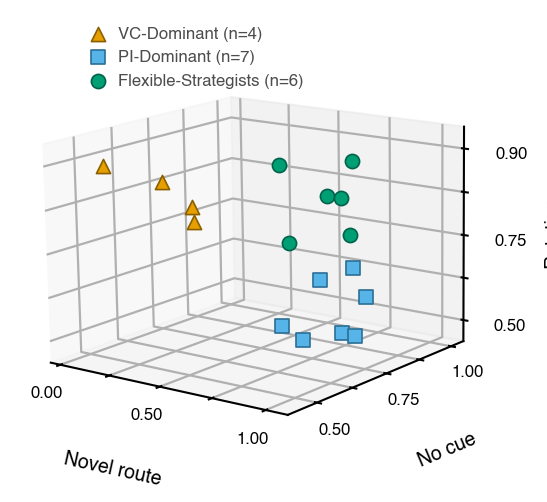

In [9]:
def panel_a(ax,
            s=None, edge_lw=None, elev=14, azim=-52, roll=1,
            xlim=(-0.05, 1.1), ylim=(0.4, 1.05), zlim=(0.45, 0.95),
            labelpad=(2, 2, -2), tickpad=(-2, -2, 2),
            show_legend=True, legend_fontsize=6,
            legend_anchor=(0.10, 1.02), order=None):
    '''Panel A: 3-D scatter of the three probe scores (proportions).

    Markers use the shared data-point recipe (= Panel D's nodes): per-cluster
    shape (o/s/^), base-hue face, dark-shade ('edge') border.
    '''
    s = STYLE_CFG['scatter3d_s'] if s is None else s
    edge_lw = STYLE_CFG['marker_edge_lw'] if edge_lw is None else edge_lw
    order = DISPLAY_ORDER if order is None else order      # legend order
    for name in order:
        c = CLUSTER_ORDER.index(name)
        m = (scores['cluster'] == c).to_numpy()
        ax.scatter(X_raw[m, 0], X_raw[m, 1], X_raw[m, 2],
                   color=CLUSTER_COLORS[name]['dark'], s=s,
                   marker=CLUSTER_MARKER[name],
                   edgecolor=CLUSTER_COLORS[name]['edge'], linewidth=edge_lw,
                   depthshade=False, label=f'{name} (n={m.sum()})')
    ax.set_xlabel('Novel route', labelpad=labelpad[0])
    ax.set_ylabel('No cue', labelpad=labelpad[1])
    ax.set_zlabel('Rotation', labelpad=labelpad[2])
    ax.tick_params(axis='x', pad=tickpad[0])   # tick-number distance from the axis line (pt)
    ax.tick_params(axis='y', pad=tickpad[1])
    ax.tick_params(axis='z', pad=tickpad[2])
    ax.view_init(elev=elev, azim=azim, roll=roll)

    # 5 gridlines per axis; label 3 (low / mid / high).
    axis_tick_labels = {0: [0.0, 0.5, 1.0], 1: [0.5, 0.75, 1.0],
                        2: [0.5, 0.75, 0.9]}
    for ci, axis in enumerate([ax.xaxis, ax.yaxis, ax.zaxis]):
        vals = axis_tick_labels[ci]
        axis.set_ticks(np.linspace(vals[0], vals[-1], 5))
        lab = [''] * 5
        lab[0], lab[2], lab[4] = f'{vals[0]:.2f}', f'{vals[1]:.2f}', f'{vals[2]:.2f}'
        axis.set_ticklabels(lab)
    ax.set_xlim(*xlim); ax.set_ylim(*ylim); ax.set_zlim(*zlim)
    if show_legend:
        leg = ax.legend(loc='upper left', frameon=False, fontsize=legend_fontsize,
                        bbox_to_anchor=legend_anchor, handletextpad=0.2)
        for t in leg.get_texts():
            t.set_color(STYLE_CFG['legend_content_color'])

_fig = plt.figure(figsize=(3.2, 3.0))
_ax = _fig.add_subplot(111, projection='3d')
panel_a(_ax)
plt.show()


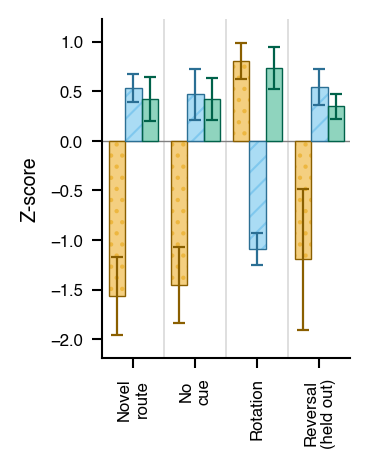

In [10]:
def panel_a_profile(ax, bar_w=0.8, bar_edge_lw=None, err_lw=None, cap_size=2,
                    order=None, xticklabels=None, xtick_rotation=90,
                    ylabel='Z-score', ylim=None, show_dividers=True,
                    held_out_label=False, show_legend=False, legend_fontsize=5.5):
    '''Panel A (right): z-scored mean ± SEM per cluster, all four variables.

    z-scores are computed across the 17 rats per variable (StandardScaler),
    so each bar = the cluster's deviation from the cohort mean. Bars use the
    Figs 2-4 recipe exactly: light-tint fill -> MID-TONE hatch (the 'hatch'
    color, PI '///', VC '...', PI+VC none) -> dark-shade border drawn LAST, so
    the border runs over the hatch and the hatch reads as texture rather than
    as marks. SEM uses the sample SD (ddof=1) over the rats scored on each variable.
    '''
    bar_edge_lw = STYLE_CFG['bar_edge_lw'] if bar_edge_lw is None else bar_edge_lw
    err_lw = STYLE_CFG['bar_err_lw'] if err_lw is None else err_lw
    order = DISPLAY_ORDER if order is None else order
    if xticklabels is None:
        xticklabels = ['Novel\nroute', 'No\ncue', 'Rotation', 'Reversal\n(held out)']
    # NaN (unscorable Reversal, see REV_SCORE) is ignored by the scaler's fit and kept
    # in transform, so the Reversal bar averages the N_REV scored rats.
    all_z = StandardScaler().fit_transform(scores[ALL_VARS].to_numpy(float))
    x = np.arange(len(ALL_VARS))
    bw = bar_w / len(order)
    for j, name in enumerate(order):
        c = CLUSTER_ORDER.index(name)
        m = (scores['cluster'] == c).to_numpy()
        n_obs = np.sum(~np.isnan(all_z[m]), axis=0)
        means = np.nanmean(all_z[m], axis=0)
        sems = np.nanstd(all_z[m], axis=0, ddof=1) / np.sqrt(n_obs)
        off = (j - (len(order) - 1) / 2) * bw
        edge = CLUSTER_COLORS[name]['edge']
        ax.bar(x + off, means, bw,                      # pass 1 — light-tint fill
               facecolor=CLUSTER_COLORS[name]['light'], edgecolor='none',
               linewidth=0, label=f'{name} (n={m.sum()})', zorder=3)
        if CLUSTER_HATCH[name]:                         # pass 2 — mid-tone hatch
            ax.bar(x + off, means, bw, facecolor='none',
                   edgecolor=CLUSTER_COLORS[name]['hatch'],
                   hatch=CLUSTER_HATCH[name], linewidth=0, zorder=3.1)
        ax.bar(x + off, means, bw, yerr=sems, capsize=cap_size,
               facecolor='none', edgecolor=edge, linewidth=bar_edge_lw,
               error_kw={'elinewidth': err_lw, 'capthick': err_lw, 'ecolor': edge},
               zorder=3.2)                              # pass 3 — border + SEM on top
    ax.set_xticks(x)
    ax.set_xticklabels(xticklabels, rotation=xtick_rotation,
                       ha='center' if xtick_rotation in (0, 90) else 'right',
                       rotation_mode='anchor' if xtick_rotation not in (0, 90) else 'default')
    ax.set_xlim(-0.5, len(ALL_VARS) - 0.5)
    ax.set_ylabel(ylabel)
    if ylim is not None:
        ax.set_ylim(*ylim)
    else:
        ax.margins(y=0.08)   # keep the tallest SEM cap off the (hidden) top spine
    ax.axhline(0, color='0.5', lw=0.5, zorder=1)
    if show_dividers:
        for xv in x[:-1] + 0.5:
            ax.axvline(xv, color=STYLE_CFG['divider_color'], lw=0.6, zorder=0)
    if held_out_label:
        ax.text(x[-1], ax.get_ylim()[0], 'held out', fontsize=5.5, color='grey',
                style='italic', ha='center', va='bottom')
    if show_legend:   # handles built by hand: the bars are drawn in three passes
        ax.legend(handles=[Patch(facecolor=CLUSTER_COLORS[n]['light'],
                                 edgecolor=CLUSTER_COLORS[n]['edge'],
                                 hatch=CLUSTER_HATCH[n], linewidth=bar_edge_lw,
                                 label=f'{n} (n={(scores["cluster_name"] == n).sum()})')
                           for n in order],
                  frameon=False, fontsize=legend_fontsize)
    _clean_spine(ax)

_fig, _ax = plt.subplots(figsize=(1.6, 2.2))
panel_a_profile(_ax)
plt.show()


## Panel B — cluster-number selection (Gap + Calinski-Harabasz)

Both criteria peak at k = 3 on the 2-D PC clustering space. Twin y-axes,
color-coded to the two curves (no legend needed).


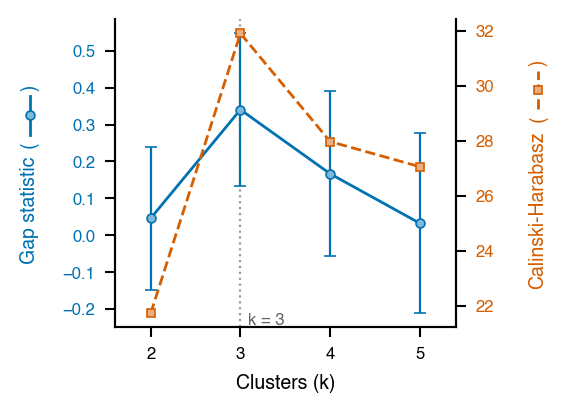

In [11]:
def panel_b(ax, marker_s=3.2, lw=1.0, cap=2, err_lw=0.8, marker_edge_lw=None,
            xlabel='Clusters (k)', show_legend=False, k_label=True,
            ylabel_gap='Gap statistic', ylabel_ch='Calinski-Harabasz',
            style_samples=True,      # each axis title is drawn as ONE measured column:
            label_x=(-0.25, 1.24),   # text + '(' + line sample + ')' stacked from the
            sample_len=0.125):       # text's rendered extent, whole block centred at 0.5.
                                     # (A pure-string label can't work: em dashes don't
                                     # join in Helvetica, so no solid-line glyph exists.)
    '''Panel B: Gap statistic (left axis) + Calinski-Harabasz (right axis) vs k.

    Marker faces are a light tint of each curve's colour (COLOR_GAP_FILL /
    COLOR_CH_FILL, set by MARKER_TINT); the lines, marker edges, error bars and
    the axis-title line samples stay at full strength.
    '''
    marker_edge_lw = STYLE_CFG['marker_edge_lw'] if marker_edge_lw is None else marker_edge_lw
    ax.errorbar(K_RANGE, gaps, yerr=sks, fmt='o-', color=COLOR_GAP, capsize=cap,
                markersize=marker_s, linewidth=lw, elinewidth=err_lw, capthick=err_lw,
                markerfacecolor=COLOR_GAP_FILL, markeredgecolor=COLOR_GAP,
                markeredgewidth=marker_edge_lw,
                label='Gap statistic', zorder=3)
    ax.set_xlabel(xlabel)
    if not style_samples:
        ax.set_ylabel(ylabel_gap, color=COLOR_GAP)
    ax.tick_params(axis='y', labelcolor=COLOR_GAP)
    ax.set_xticks(K_RANGE)
    ax.set_xlim(K_RANGE[0] - 0.4, K_RANGE[-1] + 0.4)

    ax2 = ax.twinx()
    ax2.plot(K_RANGE, [ch[k] for k in K_RANGE], 's--', color=COLOR_CH,
             markersize=marker_s, linewidth=lw,
             markerfacecolor=COLOR_CH_FILL, markeredgecolor=COLOR_CH,
             markeredgewidth=marker_edge_lw,
             label='Calinski-Harabasz', zorder=3)
    if not style_samples:
        ax2.set_ylabel(ylabel_ch, color=COLOR_CH)
    ax2.tick_params(axis='y', labelcolor=COLOR_CH)

    if style_samples:
        # Axis title + '(' + line sample + ')' as one column per side, every gap
        # measured in points from the rendered text so the parts stay in line.
        _r = ax.figure.canvas.get_renderer()
        _fpp = 1.0 / (ax.get_position().height * ax.figure.get_figheight() * 72)  # axes frac / pt
        _fs = plt.rcParams['axes.labelsize']
        def _pt(artist):   # rendered vertical extent of a rotated text, in points
            return artist.get_window_extent(_r).height / ax.figure.dpi * 72
        for x, text, color, fill, ls, mk in [
                (label_x[0], ylabel_gap, COLOR_GAP, COLOR_GAP_FILL, '-', 'o'),
                (label_x[1], ylabel_ch, COLOR_CH, COLOR_CH_FILL, '--', 's')]:
            tkw = dict(rotation=90, ha='center', fontsize=_fs, color=color,
                       transform=ax.transAxes, clip_on=False)
            t = ax.text(x, 0.5, text, va='center', **tkw)
            L = _pt(t)
            p1 = ax.text(x, 0.5, '(', va='bottom', **tkw)
            ph = _pt(p1)
            extra = 0.45 * _fs + ph + 0.30 * _fs + sample_len / _fpp + 0.30 * _fs + ph
            t.set_y(0.5 - extra / 2 * _fpp)          # centre the WHOLE block on the axis
            y = 0.5 - extra / 2 * _fpp + (L / 2 + 0.45 * _fs) * _fpp
            p1.set_y(y)
            y += (ph + 0.30 * _fs) * _fpp
            ys = (y, y + sample_len)
            kw = dict(transform=ax.transAxes, clip_on=False, zorder=5)
            ax.plot([x, x], ys, color=color, lw=lw, ls=ls, **kw)
            ax.plot([x], [sum(ys) / 2], marker=mk, ms=marker_s, color=color,
                    markerfacecolor=fill, markeredgecolor=color,
                    markeredgewidth=marker_edge_lw, **kw)
            ax.text(x, ys[1] + 0.30 * _fs * _fpp, ')', va='bottom', **tkw)

    ax.axvline(3, color='#999999', linestyle=':', linewidth=0.8, zorder=0)
    if k_label:   # bottom-right of the dotted line (top is occupied by the k=3 peak)
        ax.text(3.08, ax.get_ylim()[0], 'k = 3', fontsize=6, color='#666666',
                ha='left', va='bottom')
    if show_legend:
        h1, l1 = ax.get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()
        ax.legend(h1 + h2, l1 + l2, frameon=False, fontsize=6, loc='lower left')
    ax.spines['top'].set_visible(False)
    ax2.spines['top'].set_visible(False)
    return ax2

_fig, _ax = plt.subplots(figsize=(2.2, 2.0))
panel_b(_ax)
plt.show()


## Panel C — PCA scatter with 95 % confidence ellipses

PC1 × PC2 of the three z-scored clustering variables (the space k-means ran
in), colored + shaped by cluster. Ellipse = 95 % confidence region of each
cluster's 2-D covariance (chi-square(2) = 5.991).


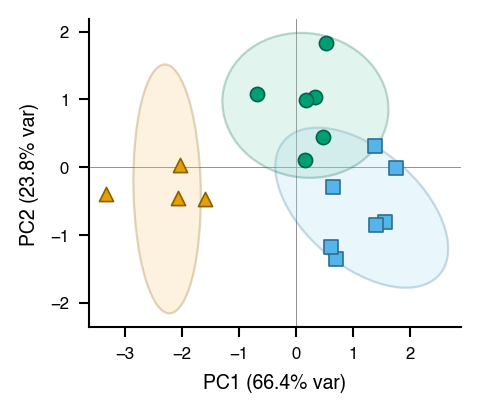

In [12]:
def panel_c(ax, s=None, edge_lw=None, annotate=False, show_legend=False,
            ellipse_alpha=None, ellipse_lw=0.8, xlabel_fmt='PC1 ({:.1%} var)',
            ylabel_fmt='PC2 ({:.1%} var)'):
    '''Panel C: PC1 vs PC2 with 95 % confidence ellipses per cluster.

    Markers use the shared data-point recipe (= Panel D's nodes): per-cluster
    shape (o/s/^), base-hue face, dark-shade ('edge') border.
    '''
    s = STYLE_CFG['scatter3d_s'] if s is None else s
    edge_lw = STYLE_CFG['marker_edge_lw'] if edge_lw is None else edge_lw
    ellipse_alpha = STYLE_CFG['ellipse_alpha'] if ellipse_alpha is None else ellipse_alpha
    for name in DISPLAY_ORDER:
        c = CLUSTER_ORDER.index(name)
        m = (scores['cluster'] == c).to_numpy()
        xy = scores.loc[m, ['PC1', 'PC2']].to_numpy()
        ax.scatter(xy[:, 0], xy[:, 1], color=CLUSTER_COLORS[name]['dark'],
                   marker=CLUSTER_MARKER[name], s=s,
                   edgecolor=CLUSTER_COLORS[name]['edge'],
                   linewidth=edge_lw, zorder=3, label=f'{name} (n={m.sum()})')
        if m.sum() > 2:
            cov = np.cov(xy[:, 0], xy[:, 1])
            ev, evec = np.linalg.eigh(cov)
            ang = np.degrees(np.arctan2(evec[1, 1], evec[0, 1]))
            w, h = 2 * np.sqrt(np.maximum(ev, 0) * 5.991)   # chi2(2, .95)
            ax.add_patch(Ellipse(xy.mean(0), width=w, height=h, angle=ang,
                                 edgecolor=CLUSTER_COLORS[name]['edge'],
                                 facecolor=CLUSTER_COLORS[name]['light'],
                                 alpha=ellipse_alpha, linewidth=ellipse_lw, zorder=2))
        if annotate:
            for xi, yi, nm in zip(xy[:, 0], xy[:, 1], scores.loc[m, 'name']):
                ax.annotate(nm, (xi, yi), fontsize=4, alpha=0.55,
                            ha='center', va='bottom')
    ax.set_xlabel(xlabel_fmt.format(var[0]))
    ax.set_ylabel(ylabel_fmt.format(var[1]))
    ax.axhline(0, color='grey', lw=0.3, zorder=0)
    ax.axvline(0, color='grey', lw=0.3, zorder=0)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    if show_legend:
        ax.legend(frameon=False, fontsize=5.5, loc='best')
    _clean_spine(ax)

_fig, _ax = plt.subplots(figsize=(2.4, 2.0))
panel_c(_ax)
plt.show()


## Panel D — Acquisition learning curves by cluster

Per-rat, per-session % correct (`errors == 0`) on acquisition sessions,
aligned so the criterion (final) session is at x = 0. Median line per
cluster + individual rat points. Same accuracy definition as Figure 2C.


In [13]:
# Per-rat, per-session acquisition accuracy, ranked from the criterion session.
acq_sessions = (sessions[(sessions['subject_id'].isin(cohort_ids)) &
                         (sessions['session_experiment_phase'] == 'Acquisition')]
                .sort_values(['subject_id', 'session_id']).copy())
acq_sessions['rank_desc'] = (acq_sessions.groupby('subject_id', observed=True)
                             .cumcount(ascending=False))
acq_trials = ptrials[ptrials['session_experiment_phase'] == 'Acquisition'].copy()
acq_trials['correct'] = (acq_trials['errors'] == 0).astype(float)
pct = (acq_trials.groupby('session_id', observed=True)['correct']
       .mean().reset_index(name='pct_correct'))
acq_acc = acq_sessions[['session_id', 'subject_id', 'rank_desc']].merge(pct, on='session_id')
acq_acc['cluster'] = acq_acc['subject_id'].map(
    scores.set_index('subject_id')['cluster'])
print('Sessions to criterion per cluster (max rank):')
print(acq_acc.groupby(acq_acc['cluster'].map(dict(enumerate(CLUSTER_ORDER))),
                      observed=True)['rank_desc'].max().to_string())


Sessions to criterion per cluster (max rank):
cluster
Flexible-Strategists     8
PI-Dominant             10
VC-Dominant              7


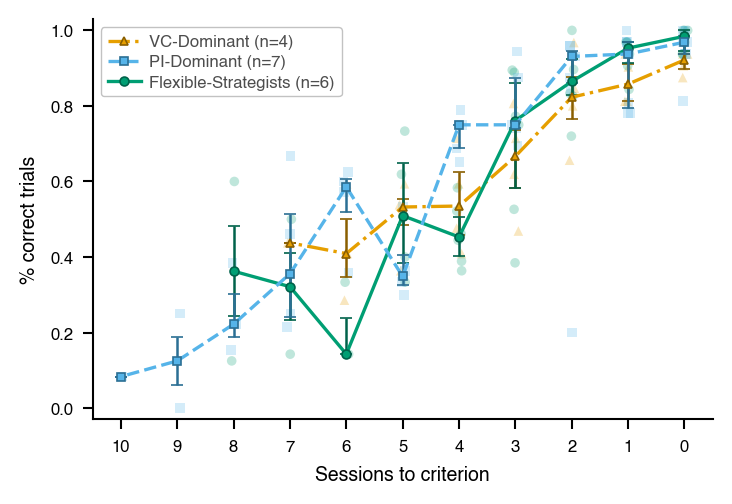

In [14]:
def panel_d(ax, line_lw=None, ind_s=None, ind_alpha=None, within_jitter=0.06,
            marker_size=None, marker_edge_lw=None, err_lw=None, cap_size=None,
            show_individual=True, ylim=(-0.03, 1.03),
            xlabel='Sessions to criterion', ylabel='% correct trials',
            show_legend=True, legend_loc='upper left', legend_fontsize=6,
            legend_frame_lw=None, legend_show_n=True, legend_bbox=None):
            # legend_show_n=False drops the '(n=..)' suffixes (they are in Panel A's
            # key); legend_bbox = a bbox_to_anchor in AXES fractions, e.g. (0, 1.30)
            # to lift the box above the plot area so it clears the curves.
    '''Panel D: acquisition curves aligned to criterion (session 0), by cluster.

    Median line + per-group node markers (o/s/^, base-hue face, dark-shade
    edge) + IQR (25-75th pct) error bars. Optional semi-transparent
    individual-rat points behind.
    '''
    line_lw = STYLE_CFG['line_lw'] if line_lw is None else line_lw
    ind_s = STYLE_CFG['ind_scatter_s'] if ind_s is None else ind_s
    ind_alpha = STYLE_CFG['ind_scatter_alpha'] if ind_alpha is None else ind_alpha
    marker_size = STYLE_CFG['marker_size'] if marker_size is None else marker_size
    marker_edge_lw = STYLE_CFG['marker_edge_lw'] if marker_edge_lw is None else marker_edge_lw
    err_lw = STYLE_CFG['err_lw'] if err_lw is None else err_lw
    cap_size = STYLE_CFG['cap_size'] if cap_size is None else cap_size
    rng = np.random.default_rng(RNG_SEED)
    x_max = int(acq_acc['rank_desc'].max())
    for c, name in enumerate(CLUSTER_ORDER):
        d = acq_acc[acq_acc['cluster'] == c]
        clr = CLUSTER_COLORS[name]['dark']
        clr_l = CLUSTER_COLORS[name]['light']
        edge = CLUSTER_COLORS[name]['edge']
        if show_individual:
            # Per-subject per-session points: base group hue, 50% transparent,
            # per-group marker shape (o/s/^).
            jit = rng.uniform(-within_jitter, within_jitter, len(d))
            ax.scatter(d['rank_desc'] + jit, d['pct_correct'], s=ind_s,
                       marker=CLUSTER_MARKER[name], facecolor=clr,
                       edgecolor='none', alpha=ind_alpha, zorder=2)
        grp = d.groupby('rank_desc', observed=True)['pct_correct']
        med = grp.median()
        xs = med.index.to_numpy()
        yerr = np.vstack([(med - grp.quantile(0.25)).to_numpy(),
                          (grp.quantile(0.75) - med).to_numpy()])
        ax.errorbar(
            xs, med.to_numpy(), yerr=yerr,
            fmt=CLUSTER_MARKER[name], ls=CLUSTER_LINE[name], color=clr,
            markerfacecolor=clr, markeredgecolor=edge,
            markeredgewidth=marker_edge_lw, markersize=marker_size,
            lw=line_lw, ecolor=edge, elinewidth=err_lw,
            capsize=cap_size, capthick=err_lw, zorder=4,
            label=f'{name} (n={d["subject_id"].nunique()})')
    ax.set_xlim(x_max + 0.5, -0.5)   # criterion (0) on the right
    ax.set_xticks(range(0, x_max + 1))
    ax.set_ylim(*ylim)
    ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1f}'))
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    _clean_spine(ax)
    if show_legend:
        legend_frame_lw = (STYLE_CFG['legend_frame_lw'] if legend_frame_lw is None
                           else legend_frame_lw)
        # Custom handles = marker + line only (no error bars on the keys).
        handles = [plt.Line2D([0], [0], color=CLUSTER_COLORS[name]['dark'],
                              ls=CLUSTER_LINE[name], marker=CLUSTER_MARKER[name],
                              markerfacecolor=CLUSTER_COLORS[name]['dark'],
                              markeredgecolor=CLUSTER_COLORS[name]['edge'],
                              markeredgewidth=marker_edge_lw, markersize=marker_size,
                              lw=line_lw,
                              label=(f'{name} (n={(scores["cluster_name"] == name).sum()})'
                                     if legend_show_n else name))
                   for name in DISPLAY_ORDER]
        leg = ax.legend(handles=handles, loc=legend_loc, frameon=True,
                        bbox_to_anchor=legend_bbox,
                        fontsize=legend_fontsize, handletextpad=0.5,
                        borderpad=0.4, labelspacing=0.3)
        frame = leg.get_frame()               # box in the Figs 2-4 style
        frame.set_linewidth(legend_frame_lw)
        frame.set_edgecolor('0.7')
        frame.set_facecolor('white')
        for t in leg.get_texts():
            t.set_color(STYLE_CFG['legend_content_color'])

_fig, _ax = plt.subplots(figsize=(4.0, 2.6))
panel_d(_ax)
plt.show()


## Panel E — Held-out Reversal: by cluster, and vs each probe score

Left: per-rat Reversal score by cluster (`DISPLAY_ORDER`; the `N_REV` scored
rats), mean ± SEM (sample SD), annotated with `E_STAT_TEXT` from the stats cell. Right: each
probe score (raw correct trials) vs the held-out Reversal score, sharing the
strip's y-axis. Stacked top marginal per panel (largest count on the bottom);
a shared right marginal shows the Reversal distribution. Dashed lines mark
the p < .01 above-chance thresholds.


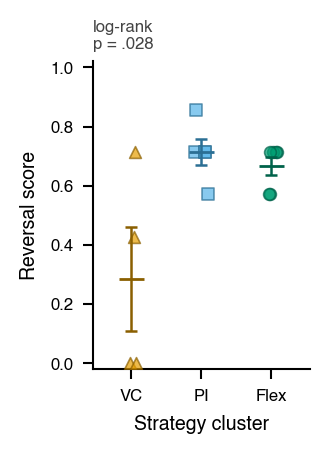

In [15]:
NICE_X = {'nr_rscr': 'Novel route\n(correct out of 16)',
          'nc_rscr': 'No cue\n(correct out of 32)',
          'rot_rscr': 'Rotation\n(correct out of 16)'}
# One-sided binomial p < .01 above-chance lines: Novel Route 9/16 at chance .25
# (p = .0075), No Cue 24/32 at .5 (p = .0035), Rotation 14/16 at .5 (p = .0021).
# (13/16 is p = .0106, so it was moved to 14 on 2026-09-24.)
THRESH = {'nr_rscr': 9, 'nc_rscr': 24, 'rot_rscr': 14}

def _stacked_marginal(ax_mh, x_col, bins, orientation='vertical'):
    '''Stacked histogram; per bin, the largest cluster count sits on the bottom.

    Three-pass bars, the Figs 2-4 recipe: pass 1 = light-tint fill, no edge;
    pass 2 = hatch strokes in the MID-TONE 'hatch' color (PI '///', VC '...',
    PI+VC none); pass 3 = the solid dark-shade border, drawn LAST so it runs
    cleanly over the hatch marks.
    '''
    counts = {c: np.histogram(scores.loc[scores['cluster'] == c, x_col].dropna(), bins=bins)[0]
              for c in range(3)}
    w = bins[1] - bins[0]
    for b in range(len(bins) - 1):
        order_b = sorted(range(3), key=lambda c: counts[c][b], reverse=True)
        base = 0
        for c in order_b:
            cnt = counts[c][b]
            if cnt == 0:
                continue
            name = CLUSTER_ORDER[c]
            fill, edge = CLUSTER_COLORS[name]['light'], CLUSTER_COLORS[name]['edge']
            hatch_c = CLUSTER_COLORS[name]['hatch']     # mid-tone, as in Figs 2-4
            hatch = CLUSTER_HATCH[name]
            bar = ax_mh.bar if orientation == 'vertical' else ax_mh.barh
            pos_kw = ({'width': w, 'bottom': base} if orientation == 'vertical'
                      else {'height': w, 'left': base})
            bar(bins[b], cnt, facecolor=fill, edgecolor='none', linewidth=0,
                align='edge', **pos_kw)                       # pass 1 — fill
            if hatch:                                    # pass 2 — mid-tone hatch
                bar(bins[b], cnt, facecolor='none', edgecolor=hatch_c,
                    hatch=hatch, linewidth=0, align='edge', **pos_kw)
            bar(bins[b], cnt, facecolor='none', edgecolor=edge, linewidth=0.5,
                align='edge', **pos_kw)                       # pass 3 — border on top
            base += cnt

def panel_e_strip(ax, s=None, alpha=None, jitter=0.10, order=None, edge_lw=None,
                  mean_w=0.36, mean_lw=None, err_lw=None, cap_size=2,
                  stat_color=None,   # None = each cluster's dark-shade 'edge'
                                     # color (Panel D's ecolor); set e.g. 'black'
                                     # to draw every mean +- SEM in one color.
                  xlabel='Strategy cluster', ylabel='Reversal score',
                  stat_text=None, stat_fontsize=6, stat_xy=(0.0, 1.03),
                  ylim=(-0.02, 1.02)):
    '''Panel E (left): per-rat Reversal score by cluster + mean ± SEM.

    Points use the shared data-point recipe (= Panel D's nodes): per-cluster
    shape, base-hue face, dark-shade border. The mean tick and SEM bars take
    that same per-cluster border color (Panel D draws its error bars in it).
    '''
    s = STYLE_CFG['scatter_s'] if s is None else s
    alpha = STYLE_CFG['scatter_alpha'] if alpha is None else alpha
    edge_lw = STYLE_CFG['marker_edge_lw'] if edge_lw is None else edge_lw
    mean_lw = STYLE_CFG['strip_mean_lw'] if mean_lw is None else mean_lw
    err_lw = STYLE_CFG['strip_err_lw'] if err_lw is None else err_lw
    order = DISPLAY_ORDER if order is None else order
    stat_text = E_STAT_TEXT if stat_text is None else stat_text
    rng = np.random.default_rng(RNG_SEED)
    for i, name in enumerate(order):
        c = CLUSTER_ORDER.index(name)
        vals = rev_groups[c]
        jx = rng.uniform(-jitter, jitter, len(vals))
        ax.scatter(np.full(len(vals), i) + jx, vals,
                   facecolor=CLUSTER_COLORS[name]['dark'], marker=CLUSTER_MARKER[name],
                   s=s, alpha=alpha, edgecolor=CLUSTER_COLORS[name]['edge'],
                   linewidth=edge_lw, zorder=3)
        m, se = vals.mean(), vals.std(ddof=1) / np.sqrt(len(vals))
        sc = CLUSTER_COLORS[name]['edge'] if stat_color is None else stat_color
        ax.hlines(m, i - mean_w / 2, i + mean_w / 2, color=sc, lw=mean_lw, zorder=4)
        ax.errorbar(i, m, yerr=se, fmt='none', ecolor=sc, elinewidth=err_lw,
                    capsize=cap_size, capthick=err_lw, zorder=4)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels([CLUSTER_SHORT[n] for n in order])
    ax.set_xlim(-0.55, len(order) - 0.45)
    ax.set_ylim(*ylim)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if stat_text:
        ax.text(*stat_xy, stat_text, transform=ax.transAxes, fontsize=stat_fontsize,
                ha='left', va='bottom', color='#444444', clip_on=False)
    _clean_spine(ax)

def panel_e(ax_scatters, ax_hists, ax_rv_hist,
            s=None, alpha=None, edge_lw=None, jitter_x_frac=0.007, jitter_y=0.005,
            ylim=(-0.02, 1.02), show_ylabel=False):
    '''Panel E (right): 3 scatter axes (+ their top marginals) + shared right marginal.

    show_ylabel=False when the Reversal strip (panel_e_strip) carries the
    shared y-axis label + ticks.
    '''
    s = STYLE_CFG['scatter_s'] if s is None else s
    alpha = STYLE_CFG['scatter_alpha'] if alpha is None else alpha
    edge_lw = STYLE_CFG['marker_edge_lw'] if edge_lw is None else edge_lw
    cols = ['nr_rscr', 'nc_rscr', 'rot_rscr']
    for idx, (x_col, ax_sc, ax_mh) in enumerate(zip(cols, ax_scatters, ax_hists)):
        xd = scores[x_col].to_numpy(float)
        x_min, x_max = xd.min(), xd.max()
        pad = (x_max - x_min) * 0.08
        x_lo, x_hi = x_min - pad, x_max + pad
        for c, name in enumerate(CLUSTER_ORDER):
            m = (scores['cluster'] == c).to_numpy()
            jx = np.random.default_rng(RNG_SEED + idx * 10 + c).normal(
                0, (x_max - x_min) * jitter_x_frac, m.sum())
            jy = np.random.default_rng(99 + idx * 10 + c).normal(0, jitter_y, m.sum())
            ax_sc.scatter(scores.loc[m, x_col] + jx, scores.loc[m, 'rev_scr'] + jy,
                          facecolor=CLUSTER_COLORS[name]['dark'], s=s, alpha=alpha,
                          marker=CLUSTER_MARKER[name],
                          edgecolor=CLUSTER_COLORS[name]['edge'],
                          linewidth=edge_lw, zorder=3)
        ax_sc.set_xlim(x_lo, x_hi)
        ax_sc.set_xlabel(NICE_X[x_col])
        ax_sc.xaxis.set_major_locator(MaxNLocator(integer=True))
        if idx == 0 and show_ylabel:
            ax_sc.set_ylabel('Reversal score')
        else:
            plt.setp(ax_sc.get_yticklabels(), visible=False)
        _clean_spine(ax_sc)
        # threshold line
        ax_sc.axvline(THRESH[x_col], color=STYLE_CFG['threshold_color'],
                      linestyle='--', linewidth=STYLE_CFG['threshold_lw'], zorder=1)
        ax_sc.text(THRESH[x_col], 0.30, 'p<.01', fontsize=6, color='#888888',
                   ha='center', va='center', rotation=90)
        # top marginal — light baseline along the bottom (bottom spine at y=0)
        x_bins = np.linspace(x_min, x_max, 9)
        _stacked_marginal(ax_mh, x_col, x_bins, 'vertical')
        ax_mh.set_xlim(x_lo, x_hi)
        ax_mh.set_ylim(bottom=0)
        ax_mh.tick_params(labelbottom=False, labelleft=False, left=False, bottom=False)
        for side, sp in ax_mh.spines.items():
            sp.set_visible(side == 'bottom')
        ax_mh.spines['bottom'].set(color=STYLE_CFG['baseline_color'],
                                   linewidth=STYLE_CFG['baseline_lw'])

    for ax_sc in ax_scatters:
        ax_sc.set_ylim(*ylim)
    # shared right marginal (reversal distribution, 10 bins). Its baseline is
    # drawn in the compose cell as one continuous corner joining the E3
    # top-marginal baseline (see `_join_marginal_corner`), so hide its spines.
    _stacked_marginal(ax_rv_hist, 'rev_scr', np.linspace(0, 1, 11), 'horizontal')
    ax_rv_hist.set_ylim(*ylim)
    ax_rv_hist.set_xlim(left=0)
    ax_rv_hist.tick_params(labelbottom=False, labelleft=False, left=False, bottom=False)
    for sp in ax_rv_hist.spines.values():
        sp.set_visible(False)

_fig, _ax = plt.subplots(figsize=(1.4, 2.0))
panel_e_strip(_ax)
plt.show()


## Composed figure


page 7.087 x 3.847 in  (510 x 277 pt)
E scatter 1.047 x 1.047 in (square) | C 1.300 x 1.300 in | D 1.850 x 1.267 in
row-1 axis height 1.300 in (profile panel = B = C) | gaps around B: left 0.470, right 0.802 in
cube box (page fractions): 0.035–0.235, centre 0.135


A legend bbox (page fractions): x 0.056–0.215, y 0.914–0.997
axes x0 / y1: {'A3d': (np.float64(0.035), np.float64(0.969)), 'Aprof': (np.float64(0.371), np.float64(0.948)), 'B': (np.float64(0.6), np.float64(0.948)), 'C': (np.float64(0.812), np.float64(0.948)), 'D': (np.float64(0.055), np.float64(0.454)), 'Estrip': (np.float64(0.381), np.float64(0.397)), 'E1': (np.float64(0.487), np.float64(0.397))}


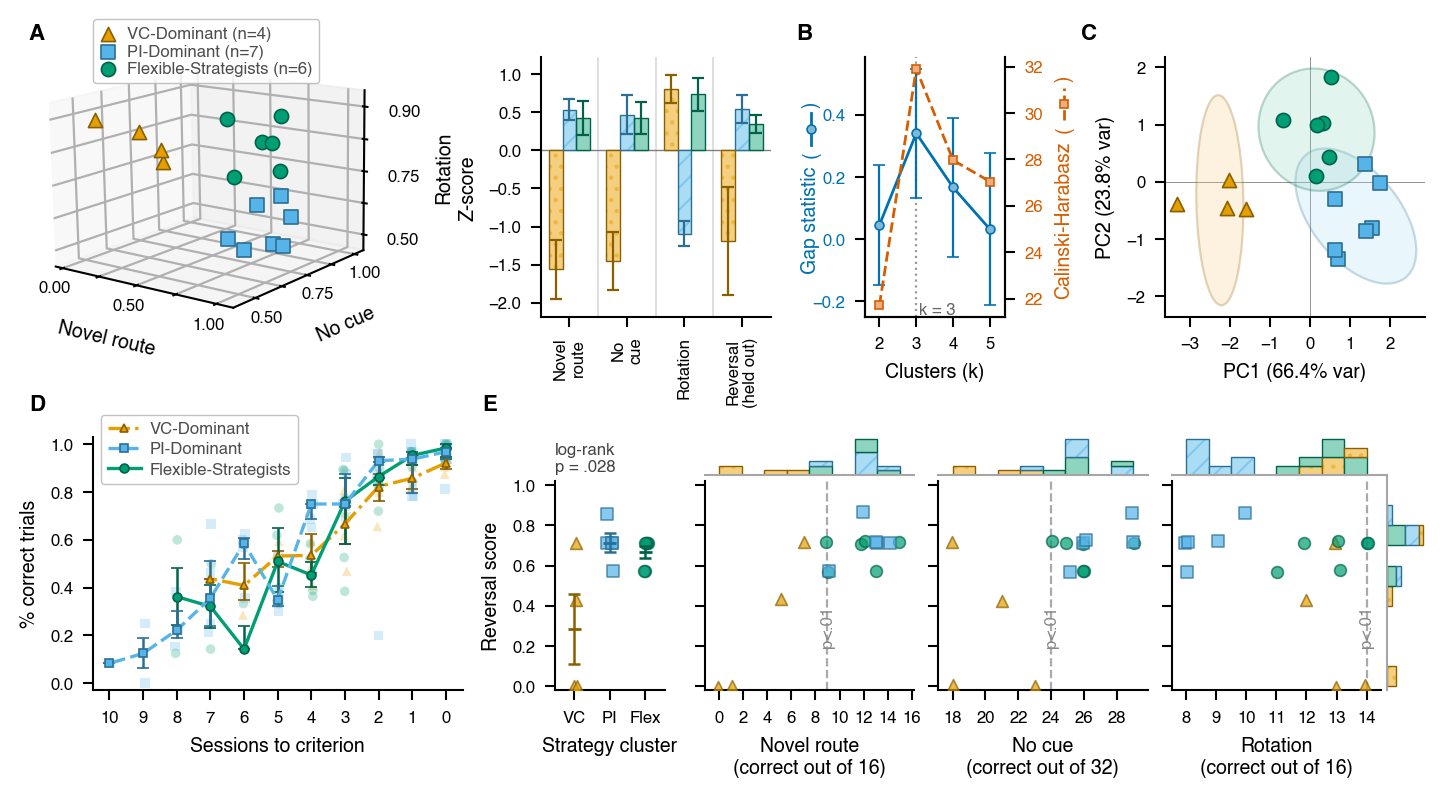

In [16]:
# Page: 180 mm wide (the Wiley full-page canvas), saved WITHOUT a tight bbox so
# every composed figure has the same width. Two rows (2026-09-24):
#   Row 1: A (3-D scatter | z-score profiles)  B (k selection)  C (PCA)
#   Row 2: D (acquisition curves)  E (Reversal strip | 3 scatters + marginals)
# EVERY layout knob below is in INCHES (the grid ratios are derived from them),
# because the binding constraint is a shape, not a page fraction: Panel E's three
# scatters must be SQUARE (user, 2026-09-24). Their side falls out of the row-2
# width budget, and row 2's cell height is then set from it — so the scatters stay
# square whatever else moves. Page height follows from the two row heights.
page_w = 180 / 25.4        # 7.087 in

MARGIN_L_IN = 0.39         # holds D's '% correct trials' label + ticks (row 1 starts further left)
MARGIN_R_IN = 0.035        # C's / the right marginal's outer edge
TOP_IN      = 0.20         # margin above row 1 (the cluster legend sits in it)
BOTTOM_IN   = 0.48         # margin below row 2 (its 2-line x labels live here)
ROW_GAP_IN  = 0.60         # between the rows: holds row 1's x labels (the profile
                           # panel's ROTATED tick labels are the tall ones, ~0.46 in)
ROW1_H_IN   = 1.30         # row 1 cell height = the SHARED axis height of the profile
                           # panel, B and C (they all fill the row cell), and C's square
                           # side. Shrinking it is what buys the air around Panel B.
CONTENT_W_IN = page_w - MARGIN_L_IN - MARGIN_R_IN     # 6.662 in

# --- Row 2 budget: D + strip + three SQUARE scatters + the shared right marginal.
D_W_IN          = 1.85     # acquisition curves (aspect ~1.46, as in the draft)
GAP_D_STRIP_IN  = 0.46     # holds E-strip's 'Reversal score' label + tick numbers
STRIP_W_IN      = 0.55     # Reversal strip: 3 x ticks (VC / PI / Flex)
GAP_STRIP_E_IN  = 0.20     # air only (the scatters' y ticks are hidden)
GAP_E_IN        = 0.12     # between scatters
MARG_H     = 0.18          # top-marginal height : scatter height (also right-marginal width)
MARG_WSP   = 0.05          # hspace/wspace inside a scatter's marginal split
# A marginal split of ratios [MARG_H, 1] with that spacing is _SPLIT x the scatter,
# in BOTH directions — so the E3 column (scatter + right marginal) and row 2's cell
# height are the same multiple of the scatter side.
_SPLIT = 1 + MARG_H + MARG_WSP * (1 + MARG_H) / 2          # 1.2095
E_W_IN = (CONTENT_W_IN - D_W_IN - GAP_D_STRIP_IN - STRIP_W_IN - GAP_STRIP_E_IN
          - 2 * GAP_E_IN) / (2 + _SPLIT)                   # square scatter side
ROW2_H_IN = _SPLIT * E_W_IN        # <- makes each scatter exactly E_W_IN tall

# --- Row 1 budget. C's axis is SQUARE BY CONSTRUCTION (C_W_IN = ROW1_H_IN) and the
# B<->C gap takes the residual, so trimming ROW1_H_IN automatically buys air on BOTH
# sides of Panel B: directly on the right, and on the left via GAP_PROF_B_IN below.
A3D_W_IN       = 1.78      # grid cell for the 3-D axes (the cube overflows it, see PANEL_A_BOX_IN)
GAP_A_PROF_IN  = 0.46      # holds the profile panel's 'Z-score' label + ticks AND keeps
                           # it off the cube's 'Rotation' z label (two rotated labels 0.08 in
                           # apart read as one block — measured min. clearance 0.20 in)
PROF_W_IN      = 1.15      # z-score profiles (rotated tick labels, so it can be narrow)
GAP_PROF_B_IN  = 0.47      # B's left 'Gap statistic' title column + air to the profile's bars
B_W_IN         = 0.70      # k-selection curves
C_W_IN = ROW1_H_IN         # PCA panel — square: its side IS row 1's axis height
GAP_B_C_IN = CONTENT_W_IN - (A3D_W_IN + GAP_A_PROF_IN + PROF_W_IN + GAP_PROF_B_IN
                             + B_W_IN + C_W_IN)   # residual: B's right title + C's 'PC2'
page_h = TOP_IN + ROW1_H_IN + ROW_GAP_IN + ROW2_H_IN + BOTTOM_IN
FIG_SIZE = (page_w, page_h)

ROW1_COLS = [('A3d', A3D_W_IN), (None, GAP_A_PROF_IN), ('Aprof', PROF_W_IN),
             (None, GAP_PROF_B_IN), ('B', B_W_IN), (None, GAP_B_C_IN), ('C', C_W_IN)]
ROW2_COLS = [('D', D_W_IN), (None, GAP_D_STRIP_IN), ('Estrip', STRIP_W_IN),
             (None, GAP_STRIP_E_IN), ('E1', E_W_IN), (None, GAP_E_IN),
             ('E2', E_W_IN), (None, GAP_E_IN), ('E3', _SPLIT * E_W_IN)]
for _name, _cols in (('row 1', ROW1_COLS), ('row 2', ROW2_COLS)):
    assert abs(sum(w for _, w in _cols) - CONTENT_W_IN) < 1e-6, f'{_name} columns do not fill the page'
ROW_WSPACE = 0.0           # wspace 0: the spacer columns above are the only gaps
ROW_HEIGHTS = [ROW1_H_IN, ROW2_H_IN]
ROW_HSPACE = ROW_GAP_IN / ((ROW1_H_IN + ROW2_H_IN) / 2)   # hspace is relative to the mean cell height
MARGINS = dict(left=MARGIN_L_IN / page_w, right=1 - MARGIN_R_IN / page_w,
               top=1 - TOP_IN / page_h, bottom=BOTTOM_IN / page_h)
print(f'page {page_w:.3f} x {page_h:.3f} in  ({page_w * 72:.0f} x {page_h * 72:.0f} pt)')
print(f'E scatter {E_W_IN:.3f} x {ROW2_H_IN / _SPLIT:.3f} in (square) | '
      f'C {C_W_IN:.3f} x {ROW1_H_IN:.3f} in | D {D_W_IN:.3f} x {ROW2_H_IN:.3f} in')
print(f'row-1 axis height {ROW1_H_IN:.3f} in (profile panel = B = C) | '
      f'gaps around B: left {GAP_PROF_B_IN:.3f}, right {GAP_B_C_IN:.3f} in')

# Panel A (3-D) box, as padding on each edge (INCHES; + = outward, − = inward)
# around the axes' ASPECT-FITTED square (get_position() applies the 3-D box aspect,
# so `pos` below is the square that fits the grid cell, not the cell itself). The
# cube is drawn at A3D_ZOOM inside that box and its labels overflow it, so these
# pads are calibrated against the rendered PNG, not computed.
# The cube is WIDTH-limited in this box, so its drawn size = the aspect-fitted square
# (= min(A3D_W_IN, ROW1_H_IN)) + left_pad + right_pad. ROW1_H_IN dropped to 1.30, so the
# pads carry +0.15 more than they used to, to hold the cube at its former 1.31-in box.
# The split between them is what places it: the cell is 0.24 in wider than the fitted
# square on each side, so the only real limits are the page edge on the left and the
# profile panel's 'Z-score' label on the right.
PANEL_A_BOX_IN = {
    'left_pad':   0.38,    # grows the box left, into the page's left margin (row 1 has no y label there)
    'top_pad':    0.10,
    'right_pad': -0.265,    # the cube's 'Rotation' z-label must clear the profile panel's 'Z-score'
    'bottom_pad': 0.052,   # box extended DOWN by twice the half-growth, so the cube grows
}                          # toward the bottom-right with its TOP edge held in place
PROFILE_KW = dict(xtick_rotation=90, bar_w=0.72)   # narrow panel -> rotated tick labels
B_LABEL_IN = (-0.27, 0.295)  # panel_b's title columns, as offsets in inches from B's
                             # left / right edge. The right one was 0.24: that left
                             # 'Calinski-Harabasz' only 0.008 in off B's tick numbers.
                             # At 0.295 it clears them by 0.069 in and still sits
                             # 0.117 in from C's 'PC2' label, so it reads as B's.
B_LABEL_X = (B_LABEL_IN[0] / B_W_IN, 1 + B_LABEL_IN[1] / B_W_IN)

def _row(spec, cols, wspace):
    gs = gridspec.GridSpecFromSubplotSpec(1, len(cols), subplot_spec=spec,
                                          width_ratios=[w for _, w in cols],
                                          wspace=wspace)
    return {k: gs[i] for i, (k, _) in enumerate(cols) if k}

fig = plt.figure(figsize=FIG_SIZE)
outer = gridspec.GridSpec(2, 1, figure=fig, height_ratios=ROW_HEIGHTS,
                          hspace=ROW_HSPACE, **MARGINS)
r1 = _row(outer[0], ROW1_COLS, ROW_WSPACE)
r2 = _row(outer[1], ROW2_COLS, ROW_WSPACE)

axA = fig.add_subplot(r1['A3d'], projection='3d')
axA2 = fig.add_subplot(r1['Aprof'])
axB = fig.add_subplot(r1['B'])
axC = fig.add_subplot(r1['C'])
axD = fig.add_subplot(r2['D'])

# Panel E: strip (no marginal, but the same nested 2-row split so its plot box
# lines up with the scatters) + three scatters with top marginals + shared
# right marginal on the last one.
def _split(spec):
    return gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=spec,
                                            height_ratios=[MARG_H, 1], hspace=MARG_WSP)
axE_strip = fig.add_subplot(_split(r2['Estrip'])[1])
axE, axE_h = [], []
for key in ('E1', 'E2'):
    g = _split(r2[key])
    axE_h.append(fig.add_subplot(g[0]))
    axE.append(fig.add_subplot(g[1], sharey=axE_strip))
gs3 = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=r2['E3'],
                                       width_ratios=[1, MARG_H], wspace=MARG_WSP)
g3l, g3r = _split(gs3[0]), _split(gs3[1])
axE_h.append(fig.add_subplot(g3l[0]))
axE.append(fig.add_subplot(g3l[1], sharey=axE_strip))
ax_rv_hist = fig.add_subplot(g3r[1], sharey=axE_strip)

# A3D_ZOOM scales the cube inside the (expanded) box — the default cube only
# fills ~60 % of it. The cluster legend is stacked (3 rows) above the cube and is
# built further down, once the cube's box is final (its anchor is that box's centre).
A_LEGEND_Y = 0.997       # frame top 0.003 below the page edge (a 1.0 anchor half-clips the border line)
A_LEGEND_NCOL = 1
A_LEGEND_LABELSPACING = 0.15
A_LEGEND_FRAME = True    # Figs 2-4 recipe: white fill, 0.7-gray 0.5 pt border
A3D_ZOOM = 1.22
A3D_LABELPAD = (-9, -9, -7.0)   # axis-title distance from the tick numbers (zoom scales this offset; more negative = closer)
A3D_TICKPAD  = (-5, -5, -1)   # tick-number distance from the axis line (pt; more negative = closer)
panel_a(axA, show_legend=False, labelpad=A3D_LABELPAD, tickpad=A3D_TICKPAD)
axA.set_box_aspect(None, zoom=A3D_ZOOM)
panel_a_profile(axA2, **PROFILE_KW)
panel_b(axB, label_x=B_LABEL_X)
panel_c(axC)
# Panel D's cluster key. Anchored by its LOWER-left corner (loc='lower left'), so the
# bottom edge lands on an exact data value whatever the legend's height turns out to be
# — here D_LEGEND_BOTTOM, i.e. flush with the 0.8 y tick (user, 2026-09-24). The box is
# 0.685 x 0.352 of D's axes once the '(n=..)' suffixes are dropped (they are still in
# Panel A's key); at that width its right edge falls at session ~3.0. Headroom above the
# axes is 0.52 in (row-1 ink over D ends 1.73 in from the page top, D's axes top is 2.25),
# so the box may rise ~0.38 in out of the axes before it would touch row 1.
D_YLIM = (-0.03, 1.03)         # panel D's y limits — also the scale for the legend anchor
D_LEGEND_BOTTOM = 0.8          # DATA units: legend's bottom edge sits on the 0.8 tick
D_LEGEND_XY = (0.0, (D_LEGEND_BOTTOM - D_YLIM[0]) / (D_YLIM[1] - D_YLIM[0]))
panel_d(axD, ylim=D_YLIM, show_legend=True, legend_loc='lower left',
        legend_show_n=False, legend_bbox=D_LEGEND_XY)
panel_e_strip(axE_strip)
panel_e(axE, axE_h, ax_rv_hist)

# Join the E3 top-marginal baseline to the right-marginal baseline as one
# continuous light corner in panel E's upper right (figure-fraction coords).
from matplotlib.lines import Line2D
_bh = axE_h[2].get_position()     # E3 top marginal
_br = ax_rv_hist.get_position()   # right marginal
_yc, _xc = _bh.y0, _br.x0         # corner = (right-marginal left, baseline height)
_ckw = dict(color=STYLE_CFG['baseline_color'], lw=STYLE_CFG['baseline_lw'],
            transform=fig.transFigure, clip_on=False, zorder=1)
fig.add_artist(Line2D([_bh.x1, _xc], [_yc, _yc], **_ckw))  # bridge E3 baseline → corner
fig.add_artist(Line2D([_xc, _xc], [_yc, _br.y0], **_ckw))  # right-marginal baseline up to corner

# Expand the 3-D panel per PANEL_A_BOX_IN (see knobs above): each edge padded
# outside its aspect-fitted square, in inches.
pos = axA.get_position()
_left   = pos.x0 - PANEL_A_BOX_IN['left_pad'] / page_w
_bottom = pos.y0 - PANEL_A_BOX_IN['bottom_pad'] / page_h
_right  = pos.x0 + pos.width  + PANEL_A_BOX_IN['right_pad'] / page_w
_top    = pos.y0 + pos.height + PANEL_A_BOX_IN['top_pad'] / page_h
axA.set_position([_left, _bottom, _right - _left, _top - _bottom])

# Cluster legend — CENTRED over the 3-D plot. Built here, after the box above is
# final, and anchored by its TOP-CENTRE to that box's horizontal centre: the cube is
# width-limited in the box, so the box's centre is the cube's centre, and the legend
# stays centred if the cube is ever resized. Placed in PAGE fractions via fig.legend
# (axes-fraction anchors on the 3-D axes are unreliable: it shrinks its box for aspect).
_hA, _lA = axA.get_legend_handles_labels()
_legA = fig.legend(_hA, _lA, loc='upper center',
                   bbox_to_anchor=((_left + _right) / 2, A_LEGEND_Y),
                   ncol=A_LEGEND_NCOL, frameon=A_LEGEND_FRAME, fontsize=6,
                   handletextpad=0.6, columnspacing=1.0, handlelength=1.0,
                   labelspacing=A_LEGEND_LABELSPACING, borderpad=0.4, borderaxespad=0)
for _t in _legA.get_texts():
    _t.set_color(STYLE_CFG['legend_content_color'])
if A_LEGEND_FRAME:                        # same frame as the Figs 2-4 / Panel E legends
    _fr = _legA.get_frame()
    _fr.set_linewidth(STYLE_CFG['legend_frame_lw'])
    _fr.set_edgecolor('0.7')
    _fr.set_facecolor('white')
print(f'cube box (page fractions): {_left:.3f}–{_right:.3f}, centre {(_left + _right) / 2:.3f}')

# Panel letters — 8 pt bold, figure-fraction coords (fig.text, not set_title).
# x = the left edge of each panel's outermost label column; the print below lists
# every panel's left edge (x0) / top (y1) to tune against.
_ROW1_LETTER_Y = 1 - 0.008
_ROW2_LETTER_Y = (BOTTOM_IN + ROW2_H_IN) / page_h + 0.055
PANEL_LETTERS = {
    'A': (0.010, _ROW1_LETTER_Y),
    'B': ((MARGIN_L_IN + A3D_W_IN + GAP_A_PROF_IN + PROF_W_IN + GAP_PROF_B_IN - 0.34) / page_w,
          _ROW1_LETTER_Y),   # 0.34 left of B's axis = just left of its 'Gap statistic' column
    'C': ((MARGIN_L_IN + CONTENT_W_IN - C_W_IN - 0.42) / page_w, _ROW1_LETTER_Y),
    'D': (0.010, _ROW2_LETTER_Y),
    'E': ((MARGIN_L_IN + D_W_IN + 0.10) / page_w, _ROW2_LETTER_Y),
}
for L, (x, y) in PANEL_LETTERS.items():
    fig.text(x, y, L, fontsize=8, fontweight='bold', va='top', ha='left')
fig.canvas.draw()
_lb = _legA.get_window_extent(fig.canvas.get_renderer()).transformed(fig.transFigure.inverted())
print(f'A legend bbox (page fractions): x {_lb.x0:.3f}–{_lb.x1:.3f}, y {_lb.y0:.3f}–{_lb.y1:.3f}')
print('axes x0 / y1:', {k: (round(a.get_position().x0, 3), round(a.get_position().y1, 3))
                        for k, a in [('A3d', axA), ('Aprof', axA2), ('B', axB), ('C', axC),
                                     ('D', axD), ('Estrip', axE_strip), ('E1', axE[0])]})

plt.show()


In [17]:
# Vector SVG of the composed figure, saved by matplotlib directly (the PDF is a
# plain single-figure savefig, so there is nothing pdftocairo is needed for) with
# the hatch <pattern> fills expanded to plain clipped strokes: Adobe Illustrator
# drops SVG pattern fills on import (see the export cell of figure2.ipynb, whose
# helpers these are). Until 2026-09-23 this cell converted the PDF with
# pdftocairo, whose output carried the hatches as pattern fills too.
import math
import re
import xml.etree.ElementTree as ET

_NS = 'http://www.w3.org/2000/svg'
ET.register_namespace('', _NS)
ET.register_namespace('xlink', 'http://www.w3.org/1999/xlink')

def _translate_d(d, dx, dy):
    """Shift an absolute-command path (M/L/Q/C/Z, as matplotlib writes) by (dx, dy)."""
    out, i = [], 0
    for t in re.findall(r'[A-Za-z]|-?(?:\d+\.?\d*|\.\d+)(?:[eE][-+]?\d+)?', d):
        if t.isalpha():
            if t not in 'MLQCZz':
                raise ValueError(f'unsupported path command {t!r}')
            out.append(t)
            i = 0
        else:
            out.append(f'{float(t) + (dx if i % 2 == 0 else dy):g}')
            i += 1
    return ' '.join(out)


def _expand_hatches(root):
    """Replace every `fill: url(#..)` that points at a matplotlib hatch <pattern>
    (a userSpaceOnUse tile in the document's own <defs>) with the same drawing done
    explicitly: the face fill (if the tile has one), then copies of the tile's
    hatch strokes - each clipped to its tile, all clipped to the shape - then the
    shape's own edge stroke on top. The now-unused <pattern> defs are removed.
    Returns the number of shapes expanded."""
    defs = root.findall(f'{{{_NS}}}defs')
    patterns = {p.get('id'): (d, p) for d in defs for p in d.findall(f'{{{_NS}}}pattern')
                if p.get('patternUnits') == 'userSpaceOnUse' and p.get('width') and p.get('height')}
    if not patterns:
        return 0
    parent = {c: p for p in root.iter() for c in p}
    num = r'-?(?:\d+\.?\d*|\.\d+)(?:[eE][-+]?\d+)?'
    n_shape = n_tile = 0
    for el in list(root.iter()):
        st = el.get('style') or ''
        m = re.search(r'fill:\s*url\(#([^)]+)\)', st)
        if not m or m.group(1) not in patterns or el.tag != f'{{{_NS}}}path' or not el.get('d'):
            continue
        pat = patterns[m.group(1)][1]
        tw, th = float(pat.get('width')), float(pat.get('height'))
        px, py = float(pat.get('x', 0)), float(pat.get('y', 0))
        shape_d = el.get('d')
        nums = [float(v) for v in re.findall(num, shape_d)]
        x0, x1, y0, y1 = min(nums[0::2]), max(nums[0::2]), min(nums[1::2]), max(nums[1::2])
        # matplotlib's tile = a background rect (the face colour; 'none' for a
        # hatch-only overlay) + the hatch strokes. A shape drawn with an edge keeps
        # its stroke-* properties next to the pattern fill in the same style string.
        rect = pat.find(f'{{{_NS}}}rect')
        face = rect.get('fill', 'none') if rect is not None else 'none'
        content = list(pat.iter(f'{{{_NS}}}path'))
        props = [p.strip() for p in st.split(';') if p.strip() and not p.strip().startswith('fill:')]
        stroke = [p for p in props if p.startswith('stroke')]
        other = [p for p in props if not p.startswith('stroke')]      # opacity, fill-opacity
        n_shape += 1
        cid = f'hatchshape{n_shape}'
        cp = ET.SubElement(defs[0], f'{{{_NS}}}clipPath', {'id': cid})
        ET.SubElement(cp, f'{{{_NS}}}path', {'d': shape_d})
        outer = ET.Element(f'{{{_NS}}}g')
        for k, v in el.attrib.items():          # keep the shape's clip-path / id / transform
            if k not in ('d', 'style'):
                outer.set(k, v)
        if other:
            outer.set('style', '; '.join(other))
        if face != 'none':                                             # 1) face fill
            ET.SubElement(outer, f'{{{_NS}}}path', {'d': shape_d, 'style': f'fill: {face}; stroke: none'})
        shape_g = ET.SubElement(outer, f'{{{_NS}}}g', {'clip-path': f'url(#{cid})'})   # 2) hatch
        for i in range(math.floor((x0 - px) / tw), math.ceil((x1 - px) / tw)):
            for j in range(math.floor((y0 - py) / th), math.ceil((y1 - py) / th)):
                dx, dy = px + i * tw, py + j * th
                n_tile += 1
                tid = f'hatchtile{n_tile}'
                tcp = ET.SubElement(defs[0], f'{{{_NS}}}clipPath', {'id': tid})
                ET.SubElement(tcp, f'{{{_NS}}}rect', {'x': f'{dx:g}', 'y': f'{dy:g}',
                                                      'width': f'{tw:g}', 'height': f'{th:g}'})
                tg = ET.SubElement(shape_g, f'{{{_NS}}}g', {'clip-path': f'url(#{tid})'})
                for c in content:
                    try:
                        ET.SubElement(tg, f'{{{_NS}}}path',
                                      {'d': _translate_d(c.get('d'), dx, dy), 'style': c.get('style', '')})
                    except ValueError:      # relative/arc commands: shift by transform instead
                        ET.SubElement(tg, f'{{{_NS}}}path',
                                      {'d': c.get('d'), 'style': c.get('style', ''),
                                       'transform': f'translate({dx:g} {dy:g})'})
        if any(re.match(r'stroke:\s*(?!none)', p) for p in stroke):       # 3) edge on top
            ET.SubElement(outer, f'{{{_NS}}}path', {'d': shape_d, 'style': 'fill: none; ' + '; '.join(stroke)})
        p = parent[el]
        p.insert(list(p).index(el), outer)
        p.remove(el)
    for d, pat in patterns.values():
        d.remove(pat)
    for d in defs:                              # matplotlib's trailing hatch-only <defs>
        if len(d) == 0 and d in parent:
            parent[d].remove(d)
    return n_shape


_svg = FIG_OUT / 'figure5.svg'
fig.savefig(_svg)
_tree = ET.parse(_svg)
_n_hatch = _expand_hatches(_tree.getroot())
_tree.write(_svg, xml_declaration=True, encoding='utf-8')
print(f'Saved SVG: {_svg} ({_n_hatch} hatched shape(s) expanded to plain strokes)')

Saved SVG: figures/images/figure5.svg (32 hatched shape(s) expanded to plain strokes)
